# Philadelphia Murals vs. Crime Rates

## Library Imports & Folder Creation

In [500]:
import geopandas as gpd
import pandas as pd
import numpy as np
import warnings
import h3
import esda

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import combinations

from shapely.validation import make_valid
from shapely.geometry import Polygon

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from libpysal.weights import Queen
from libpysal.weights import KNN, w_union

from spreg import ML_Lag

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

In [501]:
folders = [
    'data/maps',
    'data/crime',
    'data/murals',
    'data/greenspace',
    'data/processed',
    'outputs'
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

## File Reading & DataFrame Creation

All datasets are loaded here in one place. Processing, cleaning, and analysis for each dataset occurs in its own dedicated chapter below.

In [502]:
# Maps & Boundaries

neighborhoods   = gpd.read_file('data/maps/neighborhoods.geojson')
streets         = gpd.read_file('data/maps/streets.geojson')
philly_boundary = neighborhoods.union_all()

print(neighborhoods.shape)
print(streets.shape)

(159, 6)
(41271, 32)


In [503]:
# Murals & Vacant Lots Data

murals_gdf    = gpd.read_file('data/murals/philadelphia_murals_raw.geojson')
landcare_gdf  = gpd.read_file('data/greenspace/landcare.geojson') # Philadelphia Horticultural Society (network of city action groups)
ppr_sites_gdf = gpd.read_file('data/greenspace/ppr_program_sites.geojson') # Philadelphia Parks & Recreation (city government)

print(murals_gdf.shape)
print(landcare_gdf.shape)
print(ppr_sites_gdf.shape)

(1102, 6)
(12183, 16)
(169, 11)


In [504]:
# All GeoDataFrames are aligned to the neighborhoods CRS (EPSG:4326)

TARGET_CRS = neighborhoods.crs

gdfs = {
    'neighborhoods' : neighborhoods,
    'streets'       : streets,
    'murals_gdf'    : murals_gdf,
    'landcare_gdf'  : landcare_gdf,
    'ppr_sites_gdf' : ppr_sites_gdf,
}

for name, gdf in gdfs.items():
    before = str(gdf.crs)
    if gdf.crs != TARGET_CRS:
        gdfs[name] = gdf.to_crs(TARGET_CRS)
     

In [505]:
# Crime Data

crime_df = pd.read_csv(
    'data/crime/philly_crime.csv',
    dtype={
        'dc_dist'          : 'str',
        'psa'              : 'str',
        'ucr_general'      : 'str',
        'text_general_code': 'str',
        'hour'             : 'Int64',
        'point_x'          : 'float64',
        'point_y'          : 'float64',
    },
    low_memory=False
)

print(crime_df.shape)

(3336196, 18)


## Maps & Boundaries Data Cleaning

In [506]:
# Diagnostics

print('Neighborhoods:')
print(f'  Shape: {neighborhoods.shape}')
print(f'  CRS: {neighborhoods.crs}')
print(f'  Columns: {list(neighborhoods.columns)}')
print(f'  Invalid geometries: {(~neighborhoods.geometry.is_valid).sum()}')

print('\nStreets:')
print(f'  Shape: {streets.shape}')
print(f'  CRS: {streets.crs}')
print(f'  Columns: {list(streets.columns)}')
print(f'  Invalid geometries: {(~streets.geometry.is_valid).sum()}')

Neighborhoods:
  Shape: (159, 6)
  CRS: EPSG:4326
  Columns: ['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry']
  Invalid geometries: 0

Streets:
  Shape: (41271, 32)
  CRS: EPSG:4326
  Columns: ['fnode_', 'tnode_', 'lpoly_', 'rpoly_', 'length', 'stcl2_', 'stcl2_id', 'pre_dir', 'st_name', 'st_type', 'suf_dir', 'zip_left', 'zip_right', 'l_f_add', 'l_t_add', 'r_f_add', 'r_t_add', 'st_code', 'l_hundred', 'r_hundred', 'seg_id', 'oneway', 'class', 'responsibl', 'update_', 'newsegdate', 'multi_rep', 'streetlabe', 'stname', 'objectid', 'Shape__Length', 'geometry']
  Invalid geometries: 0


In [507]:
print(streets['class'].value_counts())

class
4     15496
5     15300
3      4507
2      4487
12      421
1       420
14      167
10      164
9       116
6        94
13       79
15       11
18        9
Name: count, dtype: int64


In [508]:
# Take only the first 4 classes from the street map, which relate to major highways and arterials, and then large and small streets.  
# We will not need the alleys, pathways, minor roads, etc, as it only serves to clog the map.

streets = streets[streets['class'].isin([1, 2, 3, 4])].reset_index(drop=True)

In [509]:
print(neighborhoods.head(10))

              NAME          LISTNAME          MAPNAME    Shape_Leng  \
0       BRIDESBURG        Bridesburg       Bridesburg  27814.546521   
1        BUSTLETON         Bustleton        Bustleton  48868.458365   
2       CEDARBROOK        Cedarbrook       Cedarbrook  20021.415802   
3    CHESTNUT_HILL     Chestnut Hill    Chestnut Hill  56394.297195   
4       EAST_FALLS        East Falls       East Falls  27400.776417   
5  MOUNT_AIRY_EAST  Mount Airy, East  East Mount Airy  28845.549808   
6      GRAYS_FERRY       Grays Ferry      Grays Ferry  25521.572356   
7            OLNEY             Olney            Olney  32197.205271   
8   PENNYPACK_PARK    Pennypack Park   Pennypack Park  87084.285589   
9         SOMERTON          Somerton         Somerton  55054.575496   

     Shape_Area                                           geometry  
0  4.458626e+07  MULTIPOLYGON (((-75.06773 40.0054, -75.06765 4...  
1  1.140504e+08  MULTIPOLYGON (((-75.0156 40.09487, -75.01768 4...  
2  2.487174

## Murals Data Cleaning

In [510]:
print(f"Shape: {murals_gdf.shape}")
print(f"CRS: {murals_gdf.crs}")
print(f"Invalid geometries: {(~murals_gdf.geometry.is_valid).sum()}")
print(f"Null geometries: {murals_gdf.geometry.isna().sum()}")
print(f"Year created range: {murals_gdf['year_created'].min()} - {murals_gdf['year_created'].max()}")
print(f"Missing year_created: {murals_gdf['year_created'].isna().sum()}")
print(f"\nColumns:\n{list(murals_gdf.columns)}")
print(f"\nHead:\n{murals_gdf.head()}")

Shape: (1102, 6)
CRS: EPSG:4326
Invalid geometries: 0
Null geometries: 0
Year created range: 1983 - No data
Missing year_created: 0

Columns:
['mural_name', 'artist', 'address', 'year_created', 'media', 'geometry']

Head:
                                          mural_name  \
0                 100 Years at Milton Hershey School   
1                                         12:00 Noon   
2                                3 Cultures, 1 Heart   
3                                52nd Street Theatre   
4  56TH STREET GATEWAY: Life Underground and Wild...   

                        artist  \
0                  Jared Bader   
1                Frito Bastien   
2              Parris Stancell   
3           Jonathan Laidacker   
4  Kala Hagopian @HagopianArts   

                                             address year_created  \
0   E Governor Rd, Hershey, Pennsylvania, 17033, USA         2008   
1  6340 Wayne Ave, Philadelphia, Pennsylvania, 19...         2007   
2  2721 N 5th St, Philadelphi

In [511]:
# Clean mural year_created column

def clean_mural_year(val):
    if val == 'No data':
        return pd.NA
    # Handle full date strings like '2009-01-01' or '2012-03-15'
    # by extracting just the year component
    if isinstance(val, str) and len(val) > 4 and '-' in val:
        try:
            return int(val[:4])
        except:
            return pd.NA
    try:
        return int(val)
    except:
        return pd.NA

murals_gdf['year_int'] = murals_gdf['year_created'].apply(clean_mural_year).astype('Int64')

print("Cleaning results:")
print(f"  Total murals          : {len(murals_gdf):,}")
print(f"  Valid years           : {murals_gdf['year_int'].notna().sum():,}")
print(f"  No data (NA)          : {murals_gdf['year_int'].isna().sum():,}")
print(f"  Year range            : {murals_gdf['year_int'].min()} – {murals_gdf['year_int'].max()}")
print(f"\nMurals usable for DiD (2006–2024):")

did_murals = murals_gdf[
    murals_gdf['year_int'].notna() &
    (murals_gdf['year_int'] >= 2006) &
    (murals_gdf['year_int'] <= 2024)
]
print(f"  {len(did_murals):,} murals across "
      f"{did_murals['year_int'].nunique()} years")
print(f"\nExcluded from DiD:")
print(f"  Pre-2006 (before crime data window) : "
      f"{(murals_gdf['year_int'] < 2006).sum():,}")
print(f"  2025–2026 (incomplete years)        : "
      f"{(murals_gdf['year_int'] >= 2025).sum():,}")
print(f"  No data                             : "
      f"{murals_gdf['year_int'].isna().sum():,}")

Cleaning results:
  Total murals          : 1,102
  Valid years           : 1,099
  No data (NA)          : 3
  Year range            : 1983 – 2026

Murals usable for DiD (2006–2024):
  835 murals across 19 years

Excluded from DiD:
  Pre-2006 (before crime data window) : 218
  2025–2026 (incomplete years)        : 46
  No data                             : 3


In [512]:
# Clip to Philadelphia boundary (removes outliers with bad coordinates)

print(f"Murals before clipping: {len(murals_gdf)}")
murals_gdf = murals_gdf[murals_gdf.geometry.within(philly_boundary)].reset_index(drop=True)
print(f"Murals after clipping: {len(murals_gdf)}")

murals_gdf.to_file('data/murals/philadelphia_murals.geojson', driver='GeoJSON')

Murals before clipping: 1102
Murals after clipping: 1092


## Greenspace Data Cleaning

In [513]:
# ── Load & align CRS ─────────────────────────────────────────────────────────

landcare_gdf  = gpd.read_file('data/greenspace/landcare.geojson')
ppr_sites_gdf = gpd.read_file('data/greenspace/ppr_program_sites.geojson')

# Explicit reassignment is safer than inplace=True inside a loop
landcare_gdf  = landcare_gdf.to_crs(neighborhoods.crs)
ppr_sites_gdf = ppr_sites_gdf.to_crs(neighborhoods.crs)

print("Loaded:")
print(f"  LandCare       : {len(landcare_gdf):,} parcels")
print(f"  PPR Sites      : {len(ppr_sites_gdf):,} program sites")

Loaded:
  LandCare       : 12,183 parcels
  PPR Sites      : 169 program sites


In [514]:
# ── Clip to Philadelphia boundary ─────────────────────────────────────────────

print("Before clipping:")
for name, gdf in [('LandCare', landcare_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    print(f"  {name}: {len(gdf):,}")

landcare_gdf  = landcare_gdf[landcare_gdf.geometry.within(philly_boundary) |
                              landcare_gdf.geometry.intersects(philly_boundary)].reset_index(drop=True)
ppr_sites_gdf = ppr_sites_gdf[ppr_sites_gdf.geometry.within(philly_boundary) |
                               ppr_sites_gdf.geometry.intersects(philly_boundary)].reset_index(drop=True)

print("\nAfter clipping:")
for name, gdf in [('LandCare', landcare_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    print(f"  {name}: {len(gdf):,}")

Before clipping:
  LandCare: 12,183
  PPR Program Sites: 169

After clipping:
  LandCare: 12,183
  PPR Program Sites: 169


In [515]:
# ── Geometry validation & repair ──────────────────────────────────────────────

for name, gdf in [('LandCare', landcare_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    n_invalid = (~gdf.geometry.is_valid).sum()
    print(f"{name}: {n_invalid} invalid geometries", end="")
    if n_invalid > 0:
        gdf['geometry'] = gdf['geometry'].apply(
            lambda g: make_valid(g) if not g.is_valid else g
        )
        n_remaining = (~gdf.geometry.is_valid).sum()
        print(f" → fixed → {n_remaining} remaining")
    else:
        print(" ✓")

print("\nFinal geometry counts:")
for name, gdf in [('LandCare', landcare_gdf), ('PPR Program Sites', ppr_sites_gdf)]:
    print(f"  {name}: {len(gdf):,} records, {(~gdf.geometry.is_valid).sum()} invalid")

LandCare: 0 invalid geometries ✓
PPR Program Sites: 0 invalid geometries ✓

Final geometry counts:
  LandCare: 12,183 records, 0 invalid
  PPR Program Sites: 169 records, 0 invalid


In [516]:
# ── EDA ───────────────────────────────────────────────────────────────────────

# --- LandCare ---
print("=== LandCare ===")
print(f"Shape         : {landcare_gdf.shape}")
print(f"CRS           : {landcare_gdf.crs}")

# Year column contains empty strings, not just NaN — handle both
landcare_gdf['year_clean'] = pd.to_numeric(
    landcare_gdf['year'].str.strip().replace('', pd.NA),
    errors='coerce'
).astype('Int64')
landcare_gdf['has_year'] = landcare_gdf['year_clean'].notna()

print(f"\nYear range    : {landcare_gdf['year_clean'].min()} – {landcare_gdf['year_clean'].max()}")
print(f"With year     : {landcare_gdf['has_year'].sum():,}  ({landcare_gdf['has_year'].mean()*100:.1f}%)")
print(f"Without year  : {(~landcare_gdf['has_year']).sum():,}  (kept — real parcels, used for density features)")

print(f"\nProgram types :\n{landcare_gdf['program'].value_counts().to_string()}")
print(f"\nStabilized    :\n{landcare_gdf['stabilized'].value_counts(dropna=False).to_string()}")
print(f"\nParcel area (sq ft):\n{landcare_gdf['parcelarea'].describe().round(1).to_string()}")

print()

# --- PPR Program Sites ---
print("=== PPR Program Sites ===")
print(f"Shape         : {ppr_sites_gdf.shape}")
print(f"CRS           : {ppr_sites_gdf.crs}")
print(f"\nProgram types :\n{ppr_sites_gdf['program_type'].value_counts().to_string()}")
print(f"\nSite classes  :\n{ppr_sites_gdf['site_class'].value_counts().to_string()}")
print(f"\nHas gym       :\n{ppr_sites_gdf['gym'].value_counts(dropna=False).to_string()}")

=== LandCare ===
Shape         : (12183, 16)
CRS           : EPSG:4326

Year range    : 1993 – 2025
With year     : 8,263  (67.8%)
Without year  : 3,920  (kept — real parcels, used for density features)

Program types :
program
PLC              7201
CLC              3269
Deeply Rooted     666
LandBank          617
PHDC              430

Stabilized    :
stabilized
YES                      8205
                         3169
NaN                       794
Needs Restabilization      14
                            1

Parcel area (sq ft):
count    12182.0
mean      1349.5
std       2101.4
min         78.0
25%        746.0
50%       1019.0
75%       1379.0
max      68081.0

=== PPR Program Sites ===
Shape         : (169, 11)
CRS           : EPSG:4326

Program types :
program_type
PPR_REC                           157
OLDER_ADULT_CENTER                  6
POOL                                3
ENVIRONMENTAL_EDUCATION_CENTER      3

Site classes  :
site_class
A    140
B     16
S     13

Has gym  

## Crime Data Cleaning

In [517]:
# Crime data: initial inspection

print(f"Shape   : {crime_df.shape}")
print(f"\nColumns : {list(crime_df.columns)}")
print(f"\nDtypes  :\n{crime_df.dtypes}")
print(f"\nHead    :\n{crime_df.head(10).to_string()}")
print(f"\nNulls   :\n{crime_df.isna().sum().to_string()}")
print(f"\nCrime types:\n{crime_df['text_general_code'].value_counts().to_string()}")

Shape   : (3336196, 18)

Columns : ['the_geom', 'cartodb_id', 'the_geom_webmercator', 'objectid', 'dc_dist', 'psa', 'dispatch_date_time', 'dispatch_date', 'dispatch_time', 'hour', 'dc_key', 'location_block', 'ucr_general', 'text_general_code', 'point_x', 'point_y', 'lat', 'lng']

Dtypes  :
the_geom                    str
cartodb_id                int64
the_geom_webmercator        str
objectid                  int64
dc_dist                     str
psa                         str
dispatch_date_time          str
dispatch_date               str
dispatch_time               str
hour                      Int64
dc_key                  float64
location_block              str
ucr_general                 str
text_general_code           str
point_x                 float64
point_y                 float64
lat                     float64
lng                     float64
dtype: object

Head    :
                                             the_geom  cartodb_id                                the_geom_we

In [518]:
# Clean and prepare for spatial join

# Drop columns not needed for analysis
keep_cols = ['dispatch_date', 'hour', 'text_general_code', 'point_x', 'point_y']
crime_df = crime_df[keep_cols].copy()

# Parse dispatch_date to datetime
crime_df['dispatch_date'] = pd.to_datetime(crime_df['dispatch_date'])
crime_df['year'] = crime_df['dispatch_date'].dt.year

# Drop rows with no coordinates — cannot be spatially joined
n_before = len(crime_df)
crime_df = crime_df.dropna(subset=['point_x', 'point_y']).reset_index(drop=True)
n_dropped = n_before - len(crime_df)
print(f"Rows before coordinate filter : {n_before:,}")
print(f"Rows dropped (no coordinates) : {n_dropped:,}  ({n_dropped/n_before*100:.1f}%)")
print(f"Rows remaining                : {len(crime_df):,}")

# Categorise crime types into three response variable groups
property_crimes = [
    'Thefts', 'Theft from Vehicle', 'Burglary Residential',
    'Burglary Non-Residential', 'Motor Vehicle Theft',
    'Vandalism/Criminal Mischief', 'Receiving Stolen Property'
]

violent_crimes = [
    'Aggravated Assault Firearm', 'Aggravated Assault No Firearm',
    'Robbery Firearm', 'Robbery No Firearm', 'Other Assaults',
    'Homicide - Criminal', 'Rape', 'Weapon Violations'
]

crime_df['crime_category'] = 'other'
crime_df.loc[crime_df['text_general_code'].isin(property_crimes), 'crime_category'] = 'property'
crime_df.loc[crime_df['text_general_code'].isin(violent_crimes),  'crime_category'] = 'violent'

print(f"\nCrime category breakdown:")
print(crime_df['crime_category'].value_counts().to_string())
print(f"\nYear range: {crime_df['year'].min()} – {crime_df['year'].max()}")
print(f"\nSample:")
print(crime_df.head(5).to_string())

Rows before coordinate filter : 3,336,196
Rows dropped (no coordinates) : 52,131  (1.6%)
Rows remaining                : 3,284,065

Crime category breakdown:
crime_category
property    1327173
other       1138445
violent      818447

Year range: 2006 – 2024

Sample:
  dispatch_date  hour    text_general_code    point_x    point_y  year crime_category
0    2006-01-14     1  Homicide - Criminal -75.178771  39.928050  2006        violent
1    2006-08-24    13  Homicide - Criminal -75.175956  39.979820  2006        violent
2    2006-01-09    16  Homicide - Criminal -75.147369  40.005607  2006        violent
3    2006-01-03     6  Homicide - Criminal -75.152912  39.925128  2006        violent
4    2006-10-05    21  Homicide - Criminal -75.080414  40.029871  2006        violent


In [519]:
# Convert to GeoDataFrame and spatial join to neighbourhoods

# Build geometry from point_x / point_y
crime_gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df['point_x'], crime_df['point_y']),
    crs='EPSG:4326'
)

print(f"Crime GeoDataFrame: {len(crime_gdf):,} rows")
print(f"CRS: {crime_gdf.crs}")

# Spatial join to neighborhoods
crime_joined = gpd.sjoin(
    crime_gdf[['geometry', 'crime_category']],
    neighborhoods[['NAME', 'geometry']],
    how='left',
    predicate='within'
)

# How many didn't fall within any neighborhood?
n_unmatched = crime_joined['NAME'].isna().sum()
print(f"\nMatched to a neighbourhood : {crime_joined['NAME'].notna().sum():,}")
print(f"Outside all neighbourhoods : {n_unmatched:,}  ({n_unmatched/len(crime_joined)*100:.1f}%)")

# Drop unmatched
crime_joined = crime_joined.dropna(subset=['NAME']).reset_index(drop=True)
print(f"Rows after dropping unmatched: {len(crime_joined):,}")

Crime GeoDataFrame: 3,284,065 rows
CRS: EPSG:4326

Matched to a neighbourhood : 3,274,551
Outside all neighbourhoods : 9,514  (0.3%)
Rows after dropping unmatched: 3,274,551


In [520]:
# Aggregate crime counts to neighbourhood level

# Total crimes per neighbourhood
total_counts = (crime_joined.groupby('NAME')
                .size()
                .reset_index(name='crime_count_total'))

# Property crimes per neighbourhood
property_counts = (crime_joined[crime_joined['crime_category'] == 'property']
                   .groupby('NAME')
                   .size()
                   .reset_index(name='crime_count_property'))

# Violent crimes per neighbourhood
violent_counts = (crime_joined[crime_joined['crime_category'] == 'violent']
                  .groupby('NAME')
                  .size()
                  .reset_index(name='crime_count_violent'))

# Merge all three together
crime_counts = (total_counts
                .merge(property_counts, on='NAME', how='left')
                .merge(violent_counts,  on='NAME', how='left')
                .fillna(0))

# Convert to int
for col in ['crime_count_total', 'crime_count_property', 'crime_count_violent']:
    crime_counts[col] = crime_counts[col].astype(int)

print(f"Crime counts shape: {crime_counts.shape}")
print(f"\nTop 10 neighbourhoods by total crime:")
print(crime_counts.sort_values('crime_count_total', ascending=False)
      .head(10).to_string(index=False))

print(f"\nDescriptive stats:")
print(crime_counts[['crime_count_total', 'crime_count_property',
                     'crime_count_violent']].describe().round(0).to_string())

Crime counts shape: (159, 4)

Top 10 neighbourhoods by total crime:
            NAME  crime_count_total  crime_count_property  crime_count_violent
UPPER_KENSINGTON             110926                 19489                23271
      HADDINGTON              86172                 18687                20252
     COBBS_CREEK              86098                 26919                25169
       FRANKFORD              84366                 25908                23434
   OXFORD_CIRCLE              70168                 29555                17485
           OLNEY              67232                 25467                21595
      HARROWGATE              65527                 22442                15030
        RICHMOND              64710                 28024                15605
           LOGAN              61249                 19258                17833
   NORTH_CENTRAL              61050                 23950                15907

Descriptive stats:
       crime_count_total  crime_count_prope

## Neighbourhood-Level Feature Matrix

Each row = one Philadelphia neighbourhood. We compute per-km² densities for each intervention type so that small and large neighbourhoods are comparable.

The feature matrix supports four model variants per algorithm:

| Model | Features | Purpose |
|---|---|---|
| **Model A** | Mural density only | Baseline: isolates mural effect, replicates prior literature |
| **Model B** | Greening density only | Greenspace-only comparison |
| **Model C** | Murals + Greening combined | Additive: tests whether combining both improves prediction |
| **Model D** | Murals + Greening + interaction term | Synergy test: does co-presence of both interventions produce non-additive effects? |

In [521]:
# Project to metric CRS for area / distance calculations

# EPSG:32618 = UTM Zone 18N (Philadelphia falls here)

CRS_METRIC = 'EPSG:32618'

nbhd_m      = neighborhoods.to_crs(CRS_METRIC).copy()
murals_m    = murals_gdf.to_crs(CRS_METRIC).copy()
landcare_m  = landcare_gdf.to_crs(CRS_METRIC).copy()
ppr_sites_m = ppr_sites_gdf.to_crs(CRS_METRIC).copy()
crime_gdf_m = crime_gdf.to_crs(CRS_METRIC).copy()

# Neighbourhood area in km²
nbhd_m['area_km2'] = nbhd_m.geometry.area / 1e6

print(f"Neighbourhood area range : {nbhd_m['area_km2'].min():.2f} – {nbhd_m['area_km2'].max():.2f} km²")
print(f"Mean neighbourhood area  : {nbhd_m['area_km2'].mean():.2f} km²")
print(f"\nProjected CRS:")
print(f"  Neighbourhoods : {nbhd_m.crs}")
print(f"  Murals         : {murals_m.crs}")
print(f"  LandCare       : {landcare_m.crs}")
print(f"  PPR Sites      : {ppr_sites_m.crs}")
print(f"  Crime          : {crime_gdf_m.crs}")

Neighbourhood area range : 0.12 – 12.00 km²
Mean neighbourhood area  : 2.32 km²

Projected CRS:
  Neighbourhoods : EPSG:32618
  Murals         : EPSG:32618
  LandCare       : EPSG:32618
  PPR Sites      : EPSG:32618
  Crime          : EPSG:32618


In [522]:
# Spatial join helper

def count_per_neighborhood(points_gdf, nbhd_gdf, col_name):
    """Spatial join points → neighborhoods, return count per NAME."""
    joined = gpd.sjoin(points_gdf[['geometry']], nbhd_gdf[['NAME', 'geometry']],
                       how='left', predicate='within')
    counts = joined.groupby('NAME').size().reset_index(name=col_name)
    return counts

In [523]:
# Mural counts per neighbourhood

mural_counts = count_per_neighborhood(murals_m, nbhd_m, 'mural_count')

print("Mural counts (top 10):")
print(mural_counts.sort_values('mural_count', ascending=False)
      .head(10).to_string(index=False))
print(f"\nTotal murals assigned to neighbourhoods: {mural_counts['mural_count'].sum():,}")

Mural counts (top 10):
              NAME  mural_count
   WEST_KENSINGTON           41
         HARTRANFT           35
  UPPER_KENSINGTON           33
      LOGAN_SQUARE           30
        CALLOWHILL           29
 WASHINGTON_SQUARE           29
     NORTH_CENTRAL           28
          FAIRHILL           25
            MANTUA           24
STRAWBERRY_MANSION           23

Total murals assigned to neighbourhoods: 1,092


In [524]:
# LandCare counts and greened area per neighbourhood

landcare_pts = landcare_m.copy()
landcare_pts['geometry'] = landcare_m.geometry.centroid
landcare_counts = count_per_neighborhood(landcare_pts, nbhd_m, 'landcare_count')

lc_joined = gpd.sjoin(
    landcare_m[['geometry', 'parcelarea']],
    nbhd_m[['NAME', 'geometry']],
    how='left', predicate='intersects'
)
lc_area = lc_joined.groupby('NAME')['parcelarea'].sum().reset_index(name='landcare_area_sqft')

print("LandCare counts (top 10):")
print(landcare_counts.sort_values('landcare_count', ascending=False)
      .head(10).to_string(index=False))
print(f"\nTotal LandCare parcels assigned: {landcare_counts['landcare_count'].sum():,}")

print("\nLandCare greened area (top 10 by sq ft):")
print(lc_area.sort_values('landcare_area_sqft', ascending=False)
      .head(10).to_string(index=False))

LandCare counts (top 10):
              NAME  landcare_count
STRAWBERRY_MANSION            1417
           STANTON            1142
         HARTRANFT            1051
     NORTH_CENTRAL             923
   WEST_KENSINGTON             695
             TIOGA             497
            MANTUA             471
       KINGSESSING             364
        HADDINGTON             336
       BREWERYTOWN             305

Total LandCare parcels assigned: 12,183

LandCare greened area (top 10 by sq ft):
              NAME  landcare_area_sqft
STRAWBERRY_MANSION           1595942.0
         HARTRANFT           1242743.0
     NORTH_CENTRAL           1198850.0
           STANTON           1185859.0
             TIOGA           1026471.0
   WEST_KENSINGTON            747902.0
            MANTUA            669821.0
       KINGSESSING            486788.0
        HADDINGTON            471537.0
          PASCHALL            386243.0


In [525]:
# PPR Program Site counts per neighbourhood

ppr_site_counts = count_per_neighborhood(ppr_sites_m, nbhd_m, 'ppr_site_count')

print("PPR Program Site counts (top 10):")
print(ppr_site_counts.sort_values('ppr_site_count', ascending=False)
      .head(10).to_string(index=False))
print(f"\nTotal PPR sites assigned: {ppr_site_counts['ppr_site_count'].sum():,}")

PPR Program Site counts (top 10):
         NAME  ppr_site_count
       MANTUA               6
  COBBS_CREEK               5
    OVERBROOK               5
       TACONY               5
     RICHMOND               5
        OLNEY               4
WEST_OAK_LANE               4
  GRAYS_FERRY               4
      MAYFAIR               3
     FISHTOWN               3

Total PPR sites assigned: 169


In [526]:
# Crime counts per neighbourhood

total_counts = (crime_joined
                .groupby('NAME')
                .size()
                .reset_index(name='crime_count_total'))

property_counts = (crime_joined[crime_joined['crime_category'] == 'property']
                   .groupby('NAME')
                   .size()
                   .reset_index(name='crime_count_property'))

violent_counts = (crime_joined[crime_joined['crime_category'] == 'violent']
                  .groupby('NAME')
                  .size()
                  .reset_index(name='crime_count_violent'))

crime_counts = (total_counts
                .merge(property_counts, on='NAME', how='left')
                .merge(violent_counts,  on='NAME', how='left')
                .fillna(0))

for col in ['crime_count_total', 'crime_count_property', 'crime_count_violent']:
    crime_counts[col] = crime_counts[col].astype(int)

print("Crime counts (top 10 by total):")
print(crime_counts.sort_values('crime_count_total', ascending=False)
      .head(10).to_string(index=False))

print(f"\nDescriptive stats:")
print(crime_counts[['crime_count_total', 'crime_count_property',
                     'crime_count_violent']].describe().round(0).to_string())

Crime counts (top 10 by total):
            NAME  crime_count_total  crime_count_property  crime_count_violent
UPPER_KENSINGTON             110926                 19489                23271
      HADDINGTON              86172                 18687                20252
     COBBS_CREEK              86098                 26919                25169
       FRANKFORD              84366                 25908                23434
   OXFORD_CIRCLE              70168                 29555                17485
           OLNEY              67232                 25467                21595
      HARROWGATE              65527                 22442                15030
        RICHMOND              64710                 28024                15605
           LOGAN              61249                 19258                17833
   NORTH_CENTRAL              61050                 23950                15907

Descriptive stats:
       crime_count_total  crime_count_property  crime_count_violent
count      

In [527]:
# Build unified feature matrix

feat = nbhd_m[['NAME', 'area_km2']].copy()

for df in [mural_counts, landcare_counts, lc_area, ppr_site_counts, crime_counts]:
    feat = feat.merge(df, on='NAME', how='left')

feat = feat.fillna(0)

print(f"Feature matrix shape after merge: {feat.shape}")
print(f"\nColumns: {list(feat.columns)}")
print(f"\nNull check:")
print(feat.isnull().sum().to_string())

Feature matrix shape after merge: (159, 9)

Columns: ['NAME', 'area_km2', 'mural_count', 'landcare_count', 'landcare_area_sqft', 'ppr_site_count', 'crime_count_total', 'crime_count_property', 'crime_count_violent']

Null check:
NAME                    0
area_km2                0
mural_count             0
landcare_count          0
landcare_area_sqft      0
ppr_site_count          0
crime_count_total       0
crime_count_property    0
crime_count_violent     0


In [528]:
# Compute density and rate columns

# Intervention densities per km²
feat['mural_density']    = feat['mural_count']    / feat['area_km2']
feat['landcare_density'] = feat['landcare_count'] / feat['area_km2']
feat['ppr_site_density'] = feat['ppr_site_count'] / feat['area_km2']

# LandCare area coverage
feat['landcare_area_km2'] = feat['landcare_area_sqft'] / 10_763_910  # sqft → km²
feat['landcare_area_pct'] = feat['landcare_area_km2']  / feat['area_km2']

# Crime rates per km²
feat['crime_rate_total']    = feat['crime_count_total']    / feat['area_km2']
feat['crime_rate_property'] = feat['crime_count_property'] / feat['area_km2']
feat['crime_rate_violent']  = feat['crime_count_violent']  / feat['area_km2']

# Model D interaction term
feat['mural_x_landcare'] = feat['mural_density'] * feat['landcare_density']

print(f"\nFeature matrix shape: {feat.shape}")
print(f"\nSample (top 10 by mural density):")
print(feat[['NAME', 'area_km2', 'mural_density', 'landcare_density',
            'ppr_site_density', 'crime_rate_total', 'mural_x_landcare']]
      .sort_values('mural_density', ascending=False)
      .head(10).to_string(index=False))


Feature matrix shape: (159, 18)

Sample (top 10 by mural density):
             NAME  area_km2  mural_density  landcare_density  ppr_site_density  crime_rate_total  mural_x_landcare
       CALLOWHILL  0.541640      53.541139          0.000000          0.000000      18157.830976          0.000000
      BELLA_VISTA  0.394599      43.081742          0.000000          2.534220      15884.491673          0.000000
         FAIRHILL  0.697557      35.839369         84.580910          2.867149      27048.688205       3031.326392
      CENTER_CITY  0.380447      34.170339          0.000000          0.000000      72866.934580          0.000000
WASHINGTON_SQUARE  0.849179      34.150628          0.000000          1.177608      58376.377577          0.000000
        GREENWICH  0.182744      32.832873         16.416437          5.472146      30271.909283        538.998788
        CHINATOWN  0.126264      23.759810          0.000000          0.000000      34594.283934          0.000000
  WEST_KENSI

In [529]:
# Descriptive statistics

print("Intervention density stats:")
print(feat[['mural_density', 'landcare_density', 'ppr_site_density',
            'mural_x_landcare']].describe().round(3).to_string())

print("\nCrime rate stats:")
print(feat[['crime_rate_total', 'crime_rate_property',
            'crime_rate_violent']].describe().round(2).to_string())

Intervention density stats:
       mural_density  landcare_density  ppr_site_density  mural_x_landcare
count        159.000           159.000           159.000           159.000
mean           6.321            56.878             0.661           590.558
std            8.891           138.089             0.934          1672.955
min            0.000             0.000             0.000             0.000
25%            0.242             0.000             0.000             0.000
50%            2.906             0.000             0.341             0.000
75%            9.131            31.094             0.952           135.371
max           53.541           971.623             5.472          8659.135

Crime rate stats:
       crime_rate_total  crime_rate_property  crime_rate_violent
count            159.00               159.00              159.00
mean           13746.81              5596.66             3257.41
std            11981.20              4990.70             2745.65
min               

In [530]:
# Standardise features for scale-sensitive models

scale_cols = [
    'mural_density', 'landcare_density', 'ppr_site_density',
    'mural_x_landcare', 'crime_rate_total',
    'crime_rate_property', 'crime_rate_violent'
]

scaler = StandardScaler()
feat_scaled = feat.copy()
feat_scaled[scale_cols] = scaler.fit_transform(feat[scale_cols])

print("Standardised feature stats (should be mean≈0, std≈1):")
print(feat_scaled[scale_cols].describe().round(3).to_string())

Standardised feature stats (should be mean≈0, std≈1):
       mural_density  landcare_density  ppr_site_density  mural_x_landcare  crime_rate_total  crime_rate_property  crime_rate_violent
count        159.000           159.000           159.000           159.000           159.000              159.000             159.000
mean           0.000            -0.000            -0.000             0.000            -0.000                0.000              -0.000
std            1.003             1.003             1.003             1.003             1.003                1.003               1.003
min           -0.713            -0.413            -0.710            -0.354            -1.147               -1.119              -1.186
25%           -0.686            -0.413            -0.710            -0.354            -0.816               -0.733              -0.872
50%           -0.385            -0.413            -0.344            -0.354            -0.100               -0.082              -0.157
75%     

In [531]:
# Save completed feature matrix

feat.to_csv('data/processed/neighborhood_features_complete.csv', index=False)
print("Saved → data/processed/neighborhood_features_complete.csv")
print(f"  Rows : {len(feat)}")
print(f"  Cols : {feat.shape[1]}")
print(f"\nFinal columns:")
for col in feat.columns:
    print(f"  {col}")

Saved → data/processed/neighborhood_features_complete.csv
  Rows : 159
  Cols : 18

Final columns:
  NAME
  area_km2
  mural_count
  landcare_count
  landcare_area_sqft
  ppr_site_count
  crime_count_total
  crime_count_property
  crime_count_violent
  mural_density
  landcare_density
  ppr_site_density
  landcare_area_km2
  landcare_area_pct
  crime_rate_total
  crime_rate_property
  crime_rate_violent
  mural_x_landcare


## Maps & Visuals

In [532]:
# Precompute LandCare centroids (polygons → points for plotting)

landcare_centroids = landcare_gdf.copy()
landcare_centroids['geometry'] = landcare_gdf.geometry.centroid
print(f"LandCare centroids: {len(landcare_centroids):,}")

LandCare centroids: 12,183


In [533]:
# Build neighbourhood adjacency list for graph colouring

neighbors_map = {name: set() for name in neighborhoods['NAME']}

for i, j in combinations(neighborhoods.index, 2):
    geom_i = neighborhoods.loc[i, 'geometry']
    geom_j = neighborhoods.loc[j, 'geometry']
    if geom_i.touches(geom_j):
        name_i = neighborhoods.loc[i, 'NAME']
        name_j = neighborhoods.loc[j, 'NAME']
        neighbors_map[name_i].add(name_j)
        neighbors_map[name_j].add(name_i)

In [534]:
# Greedy graph colouring using grey palette

greys = [
    '#f0f0f0', '#dcdcdc', '#c8c8c8', '#b4b4b4', '#a0a0a0',
    '#8c8c8c', '#787878', '#646464', '#505050', '#3c3c3c',
    '#d2d2d2', '#bebebe'
]

color_map = {}
for name in neighborhoods['NAME']:
    used = {color_map[n] for n in neighbors_map[name] if n in color_map}
    color_map[name] = next(shade for shade in greys if shade not in used)

neighborhoods['color'] = neighborhoods['NAME'].map(color_map)

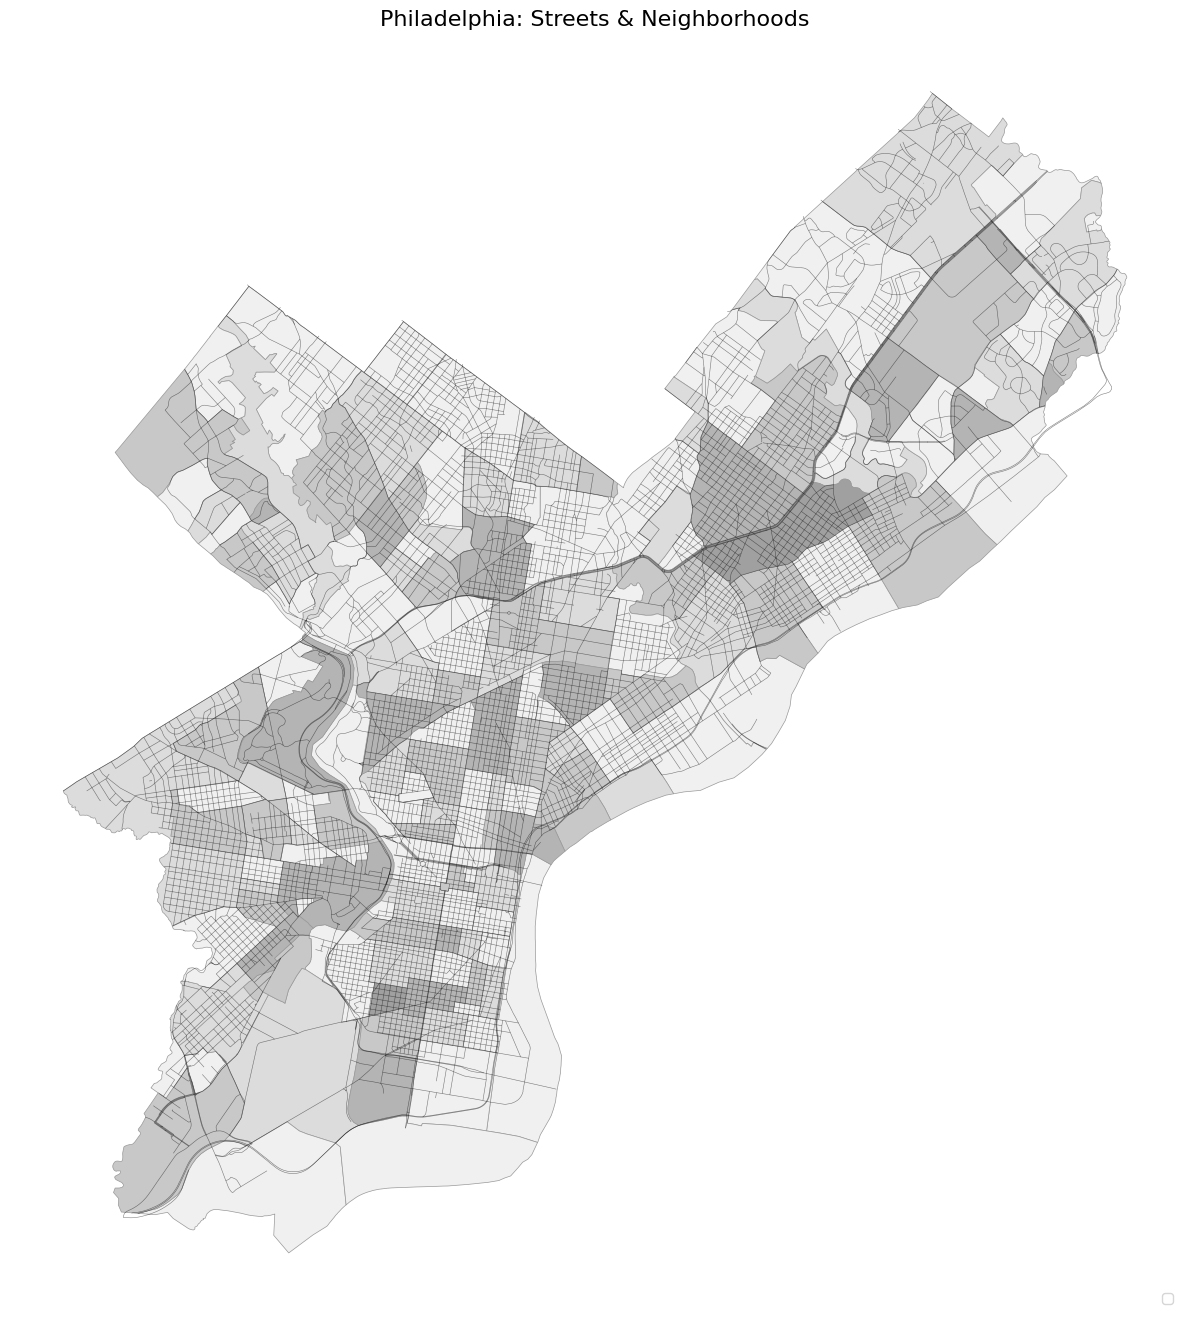

In [535]:
# Map 1: City Map only

fig, ax = plt.subplots(figsize=(12, 14))

neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)
streets.plot(ax=ax, color='black', linewidth=0.4, alpha=0.5)

ax.set_title('Philadelphia: Streets & Neighborhoods', fontsize=16)
ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/map_city_only.png', dpi=150, bbox_inches='tight')
plt.show()

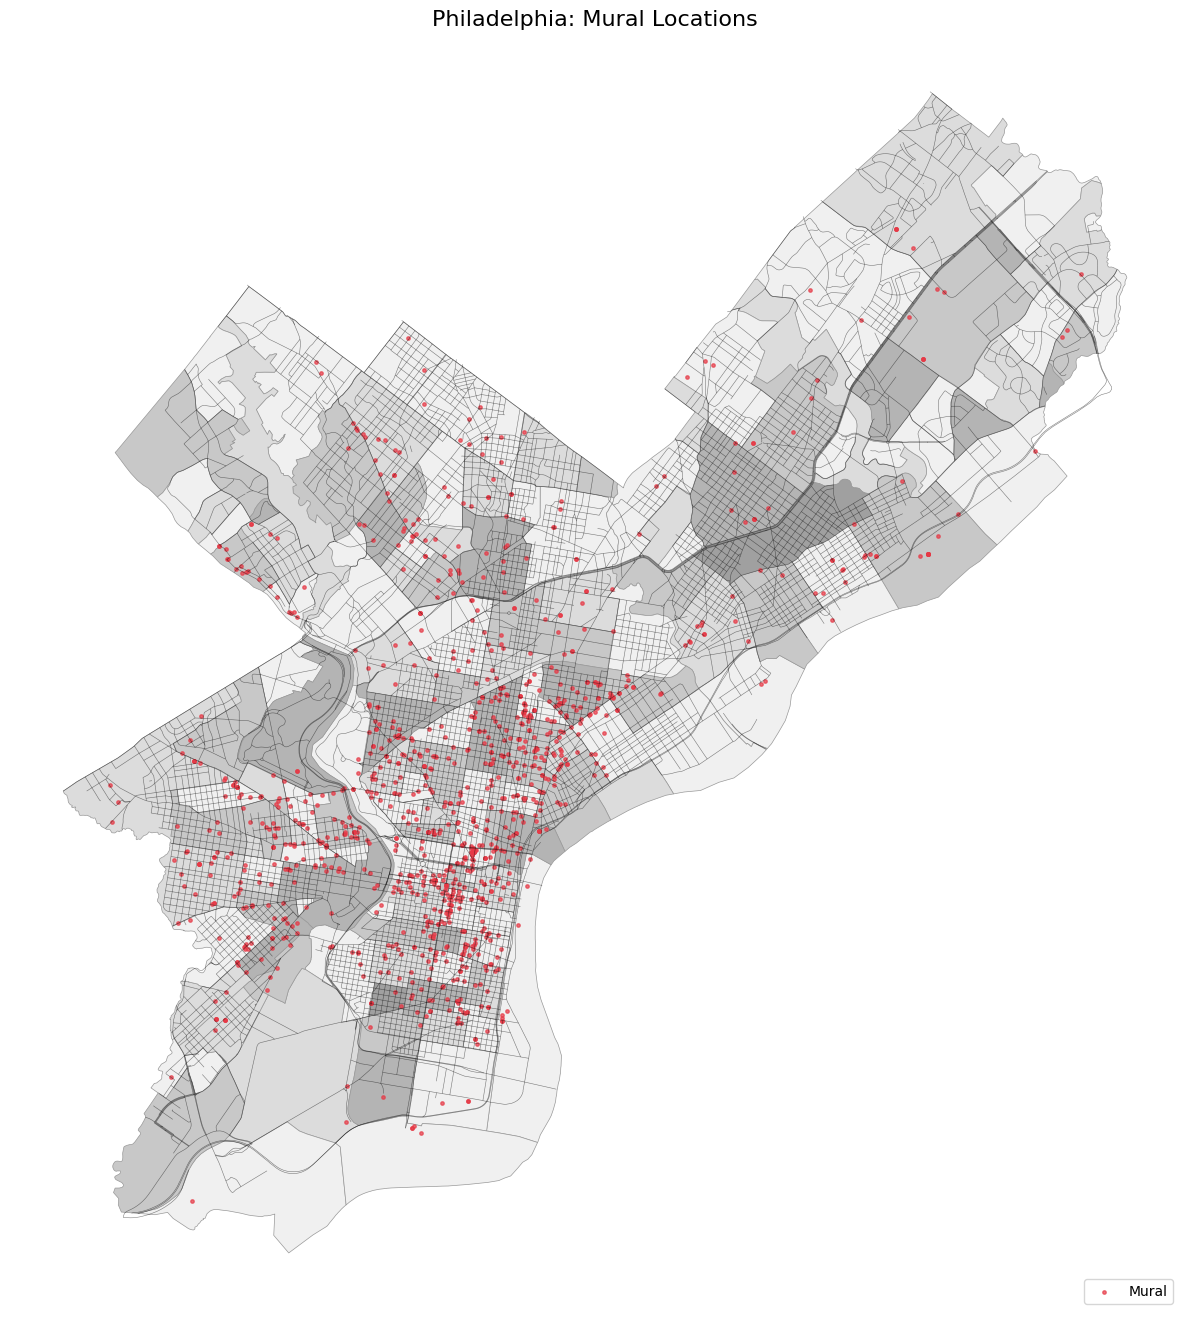

In [536]:
# Map 1: Murals only

fig, ax = plt.subplots(figsize=(12, 14))

neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)
streets.plot(ax=ax, color='black', linewidth=0.4, alpha=0.5)

murals_gdf.plot(ax=ax, color='#e63946', markersize=6, alpha=0.7, marker='o', label='Mural')

ax.set_title('Philadelphia: Mural Locations', fontsize=16)
ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/map_murals_only.png', dpi=150, bbox_inches='tight')
plt.show()

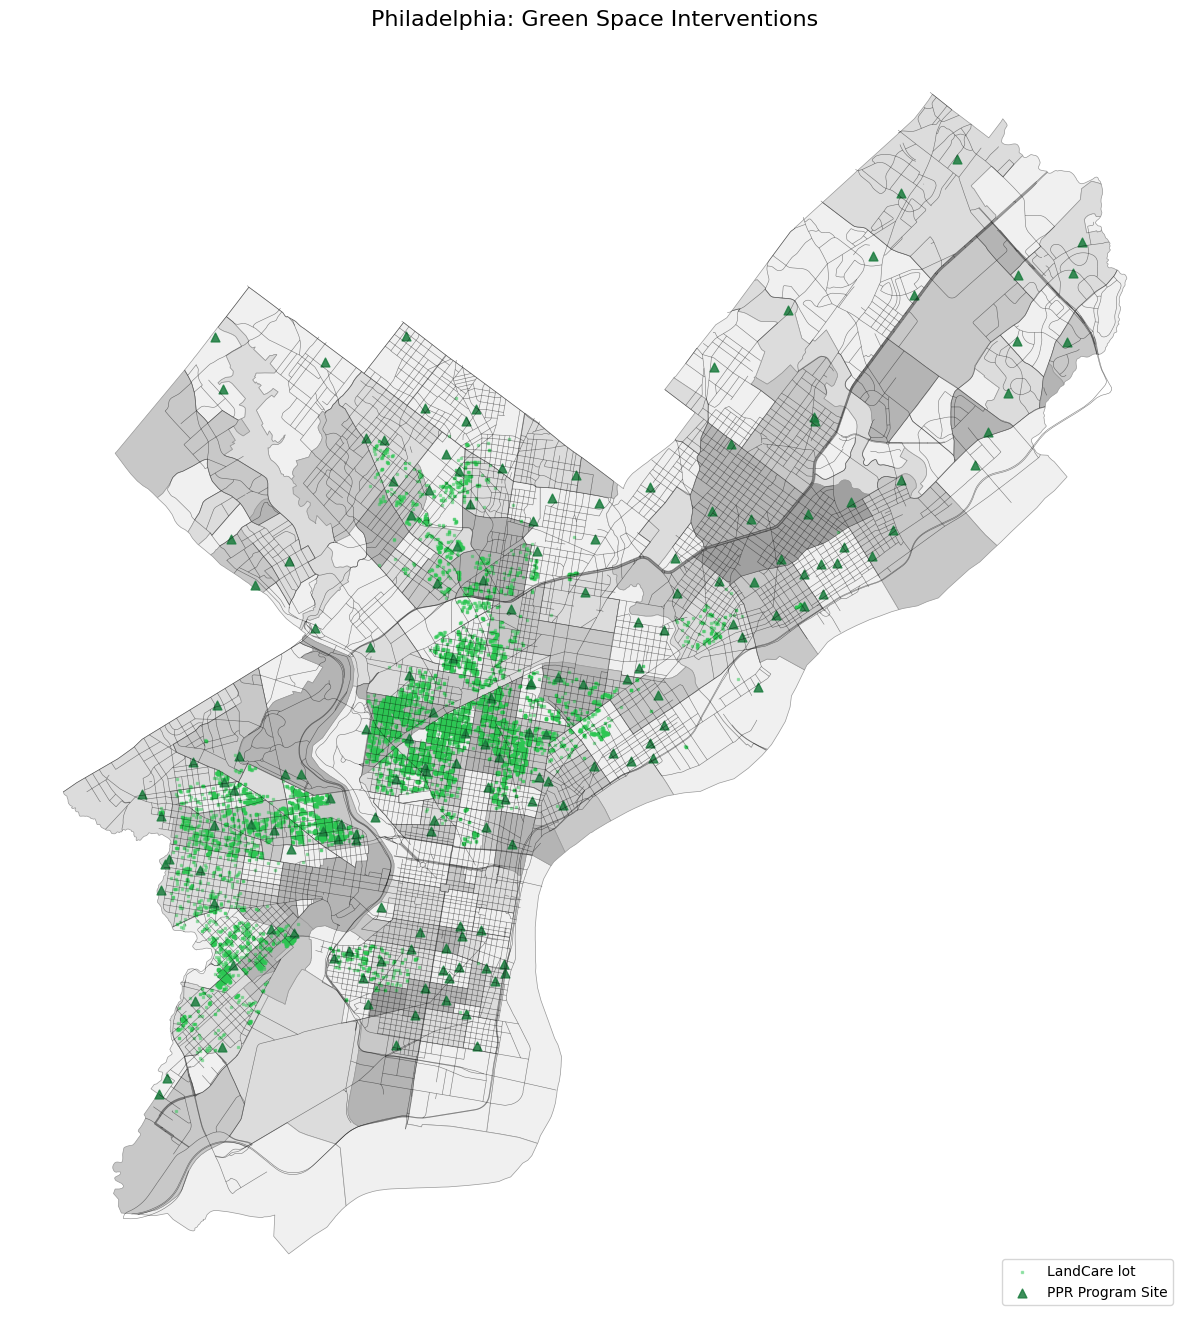

In [537]:
# Map 2: Green space only

fig, ax = plt.subplots(figsize=(12, 14))

neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)
streets.plot(ax=ax, color='black', linewidth=0.4, alpha=0.5)

landcare_centroids.plot(ax=ax, color='#2dc653', markersize=3, alpha=0.4, marker='s', label='LandCare lot')
ppr_sites_gdf.plot(ax=ax, color='#1b7c3e', markersize=40, alpha=0.85, marker='^', label='PPR Program Site')

ax.set_title('Philadelphia: Green Space Interventions', fontsize=16)
ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/map_greenspace_only.png', dpi=150, bbox_inches='tight')
plt.show()

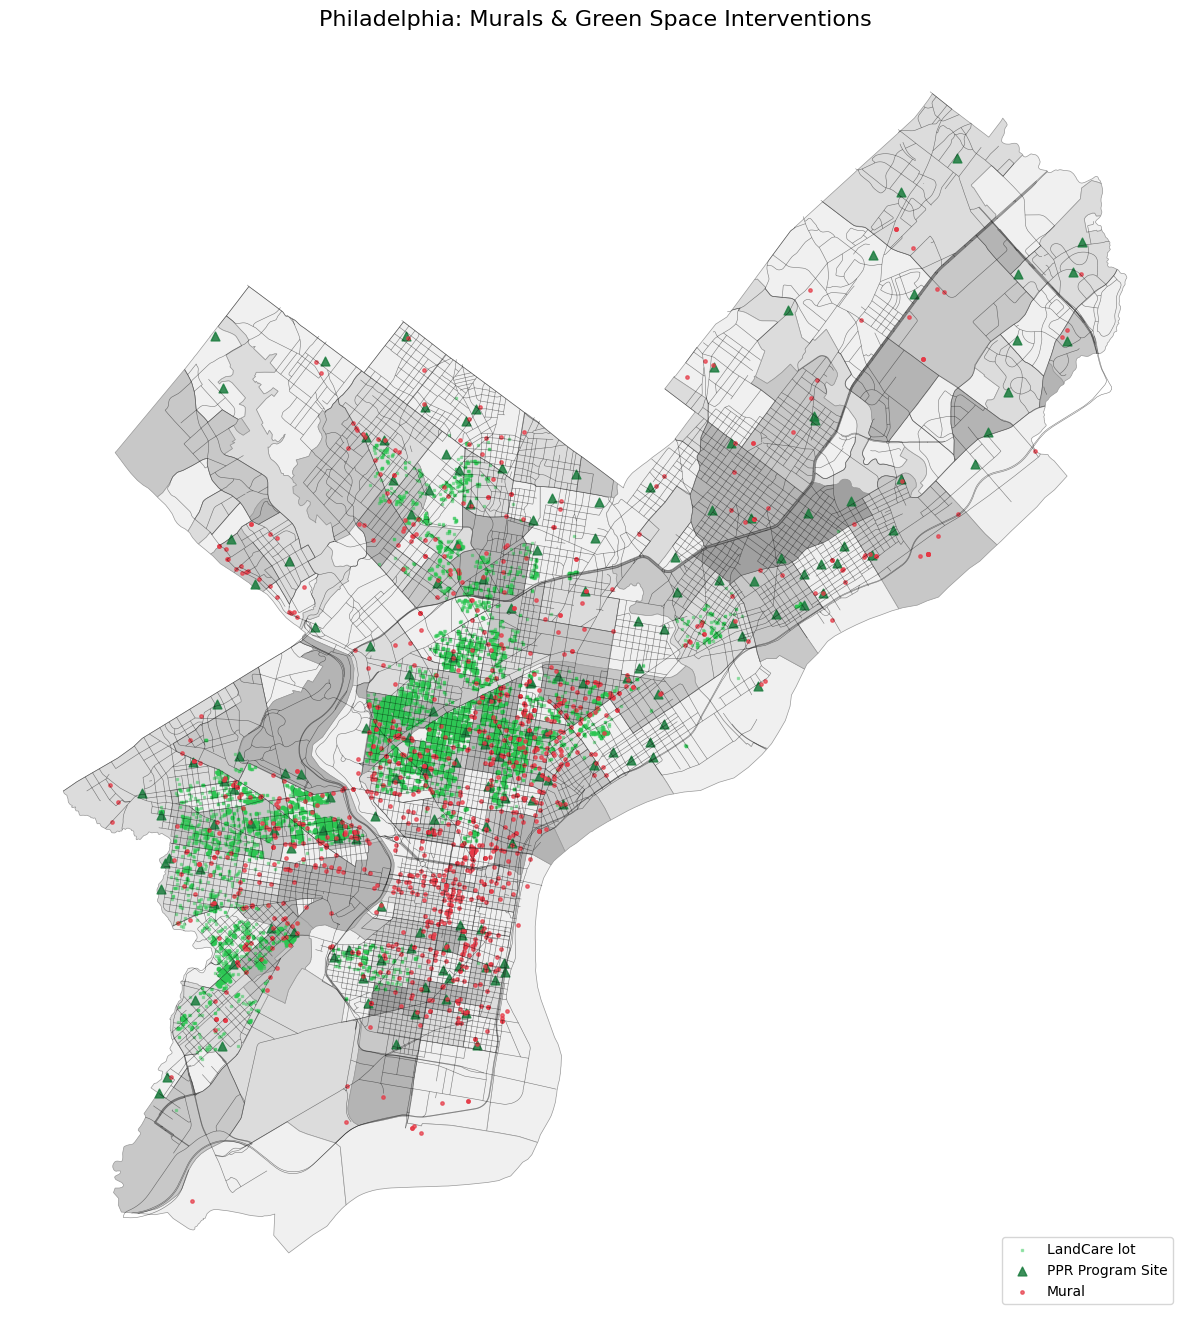

In [538]:
# Combined map: murals + all green space layers

fig, ax = plt.subplots(figsize=(12, 14))

neighborhoods.plot(ax=ax, color=neighborhoods['color'], edgecolor='#999999', linewidth=0.5)
streets.plot(ax=ax, color='black', linewidth=0.4, alpha=0.5)

landcare_centroids.plot(ax=ax, color='#2dc653', markersize=3, alpha=0.4, marker='s', label='LandCare lot')
ppr_sites_gdf.plot(ax=ax, color='#1b7c3e', markersize=40, alpha=0.85, marker='^', label='PPR Program Site')
murals_gdf.plot(ax=ax, color='#e63946', markersize=6, alpha=0.7, marker='o', label='Mural')

ax.set_title('Philadelphia: Murals & Green Space Interventions', fontsize=16)
ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/map_all_interventions.png', dpi=150, bbox_inches='tight')
plt.show()

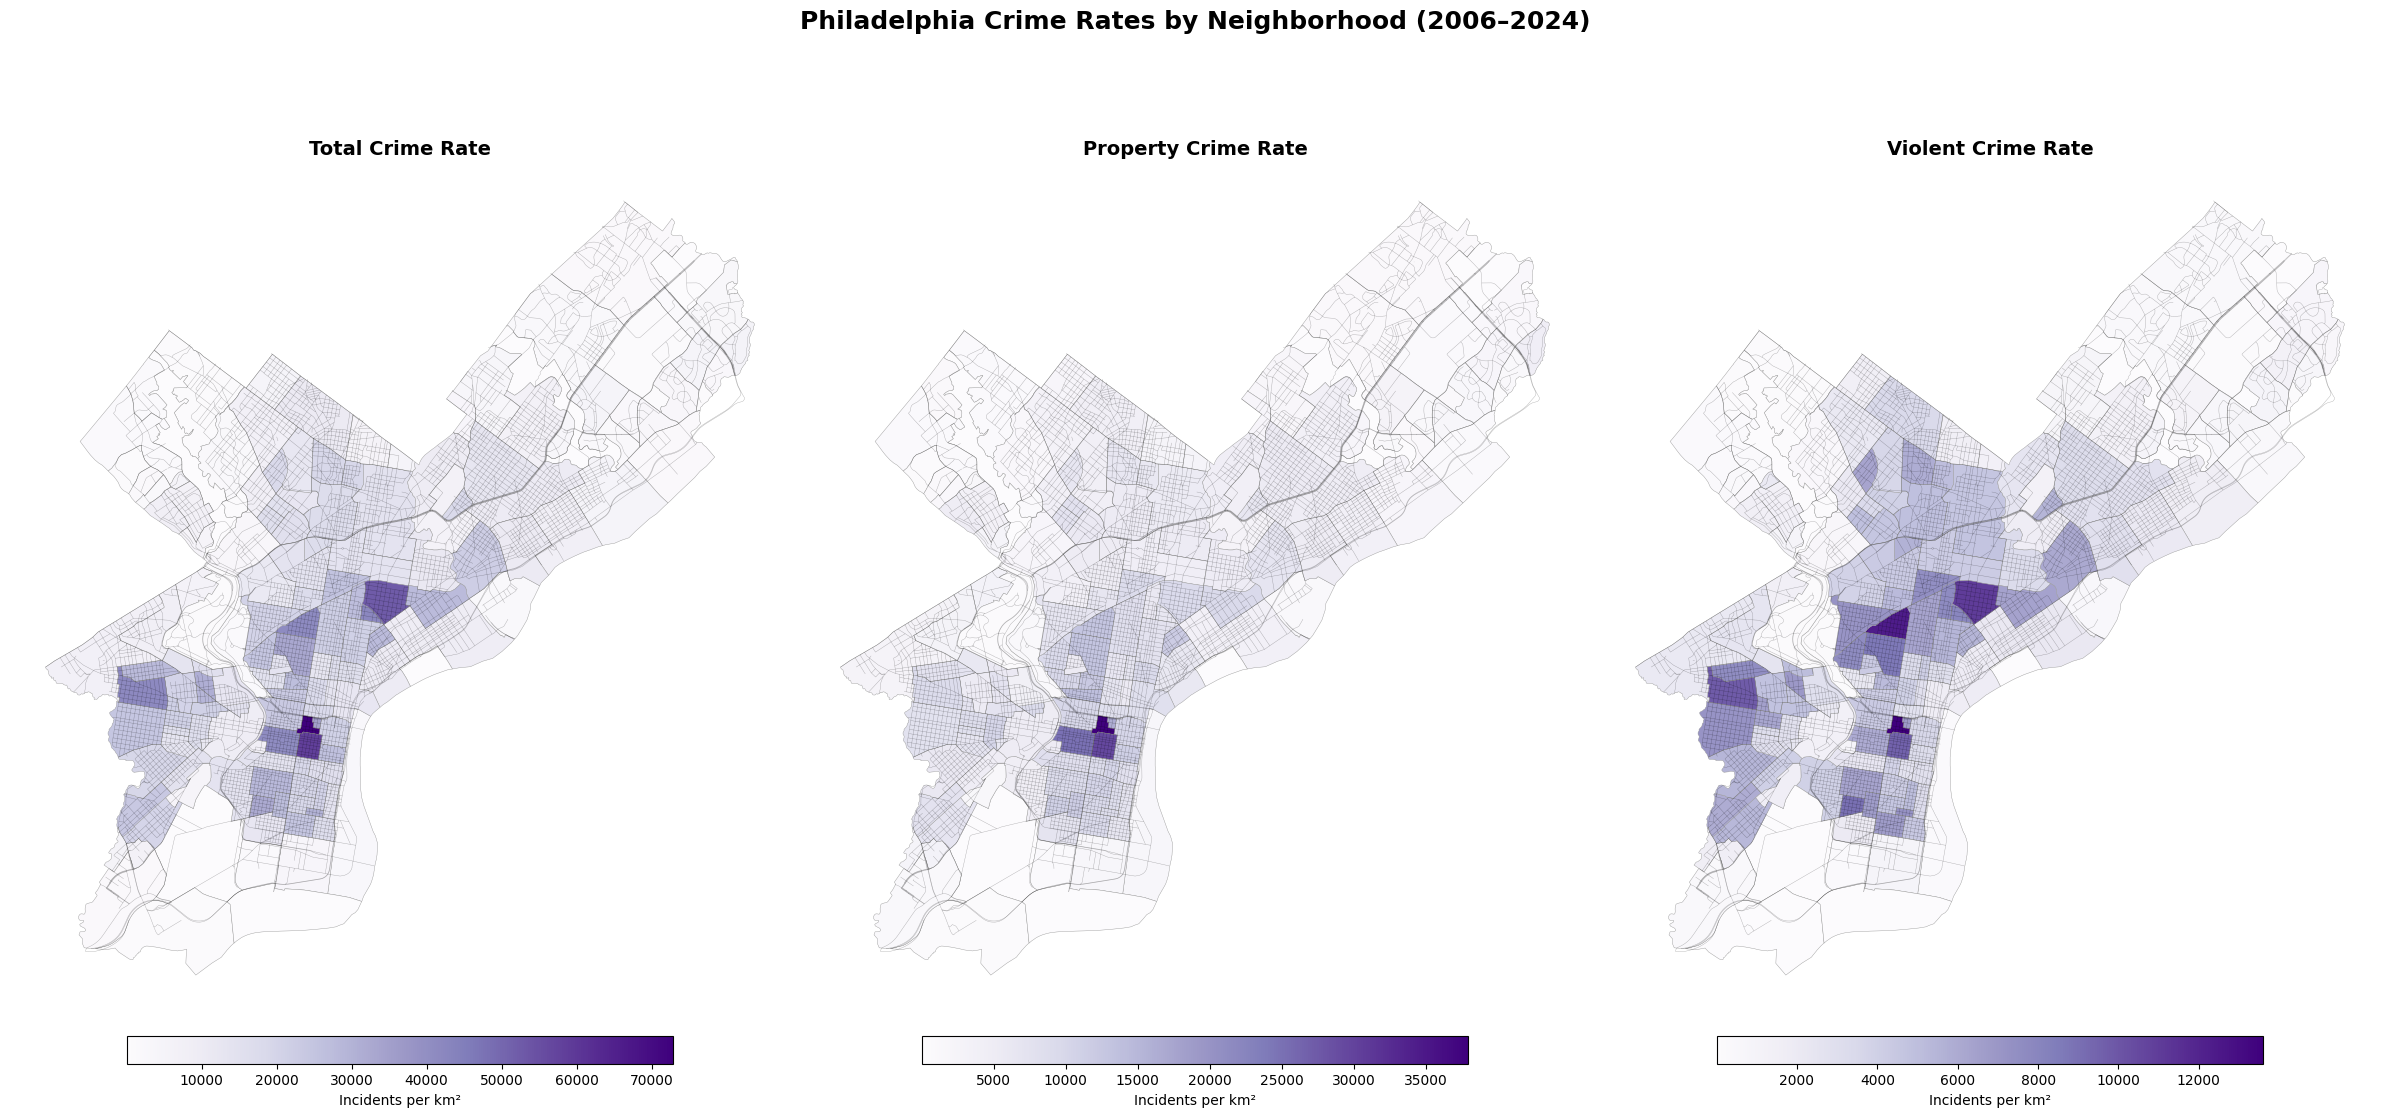

In [539]:
# Map: Crime density across Philadelphia

fig, axes = plt.subplots(1, 3, figsize=(24, 12))

crime_cols = [
    ('crime_rate_total',    'Total Crime Rate',    'Purples'),
    ('crime_rate_property', 'Property Crime Rate', 'Purples'),
    ('crime_rate_violent',  'Violent Crime Rate',  'Purples'),
]

# Merge feat back to neighborhoods GeoDataFrame for plotting
neighborhoods_plot = neighborhoods.merge(
    feat[['NAME', 'crime_rate_total', 'crime_rate_property', 'crime_rate_violent']],
    on='NAME', how='left'
)

for ax, (col, title, cmap_color) in zip(axes, crime_cols):
    neighborhoods_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap_color,
        legend=True,
        legend_kwds={
            'label'      : 'Incidents per km²',
            'orientation': 'horizontal',
            'shrink'     : 0.7,
            'pad'        : 0.02,
        },
        edgecolor='#999999',
        linewidth=0.3,
        missing_kwds={'color': 'lightgrey'},
    )
    streets.plot(ax=ax, color='black', linewidth=0.3, alpha=0.3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Philadelphia Crime Rates by Neighborhood (2006–2024)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/map_crime_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [540]:
# Hex density — crime, murals, and LandCare

# Choose hex resolution — 9 is roughly 170m cell diameter, good for neighborhood-level
HEX_RESOLUTION = 9

def points_to_hex_counts(gdf, resolution=HEX_RESOLUTION):
    """Convert a point GeoDataFrame to hex cell counts."""
    gdf_wgs = gdf.to_crs('EPSG:4326')
    hex_counts = {}
    for geom in gdf_wgs.geometry:
        if geom is None or geom.is_empty:
            continue
        h = h3.latlng_to_cell(geom.y, geom.x, resolution)
        hex_counts[h] = hex_counts.get(h, 0) + 1
    rows = []
    for h, count in hex_counts.items():
        boundary = h3.cell_to_boundary(h)
        # h3 v4 returns (lat, lng) tuples — swap to (lng, lat) for Shapely
        rows.append({
            'hex_id'  : h,
            'count'   : count,
            'geometry': Polygon([(lng, lat) for lat, lng in boundary])
        })
    return gpd.GeoDataFrame(rows, crs='EPSG:4326')

# Build hex layers
print("Building hex layers...")
crime_hex    = points_to_hex_counts(crime_gdf)
mural_hex    = points_to_hex_counts(murals_gdf.to_crs('EPSG:4326'))
landcare_hex = points_to_hex_counts(landcare_pts.to_crs('EPSG:4326'))
print(f"  Crime hex cells    : {len(crime_hex):,}")
print(f"  Mural hex cells    : {len(mural_hex):,}")
print(f"  Greened hex cells : {len(landcare_hex):,}")

# Clip to Philadelphia boundary — ensure matching CRS
philly_boundary_wgs = neighborhoods.to_crs('EPSG:4326').union_all()

crime_hex    = crime_hex[crime_hex.geometry.intersects(philly_boundary_wgs)]
mural_hex    = mural_hex[mural_hex.geometry.intersects(philly_boundary_wgs)]
landcare_hex = landcare_hex[landcare_hex.geometry.intersects(philly_boundary_wgs)]

print(f"After clipping:")
print(f"  Crime hex cells    : {len(crime_hex):,}")
print(f"  Mural hex cells    : {len(mural_hex):,}")
print(f"  Greened hex cells : {len(landcare_hex):,}")

Building hex layers...
  Crime hex cells    : 3,129
  Mural hex cells    : 576
  Greened hex cells : 590
After clipping:
  Crime hex cells    : 3,126
  Mural hex cells    : 576
  Greened hex cells : 590


In [541]:
print(f"crime_hex CRS        : {crime_hex.crs}")
print(f"neighborhoods CRS    : {neighborhoods.crs}")
print(f"philly_boundary type : {type(philly_boundary)}")
print(f"philly_boundary_wgs type : {type(philly_boundary_wgs)}")

print(f"\ncrime_hex bounds     : {crime_hex.total_bounds}")
print(f"neighborhoods bounds : {neighborhoods.total_bounds}")
print(f"philly_boundary_wgs bounds : {philly_boundary_wgs.bounds}")

print(f"\nSample hex geometry  : {crime_hex.geometry.iloc[0]}")
print(f"Sample hex centroid  : {crime_hex.geometry.iloc[0].centroid}")

# Test one intersection manually
test_hex = crime_hex.geometry.iloc[0]
print(f"\nManual intersects test: {test_hex.intersects(philly_boundary_wgs)}")

crime_hex CRS        : EPSG:4326
neighborhoods CRS    : EPSG:4326
philly_boundary type : <class 'shapely.geometry.polygon.Polygon'>
philly_boundary_wgs type : <class 'shapely.geometry.polygon.Polygon'>

crime_hex bounds     : [-75.28097522  39.87267566 -74.95476476  40.13940278]
neighborhoods bounds : [-75.28026419  39.86700576 -74.95576188  40.13799279]
philly_boundary_wgs bounds : (-75.28026418506731, 39.8670057574966, -74.95576188422399, 40.137992794380835)

Sample hex geometry  : POLYGON ((-75.17882775320821 39.92875024246637, -75.18087271340485 39.927799791380906, -75.18076081324007 39.92605781686851, -75.17860410746586 39.92526628760992, -75.17655921353017 39.926216668138814, -75.17667095910686 39.92795864848014, -75.17882775320821 39.92875024246637))
Sample hex centroid  : POINT (-75.17871592708974 39.9270082607443)

Manual intersects test: True


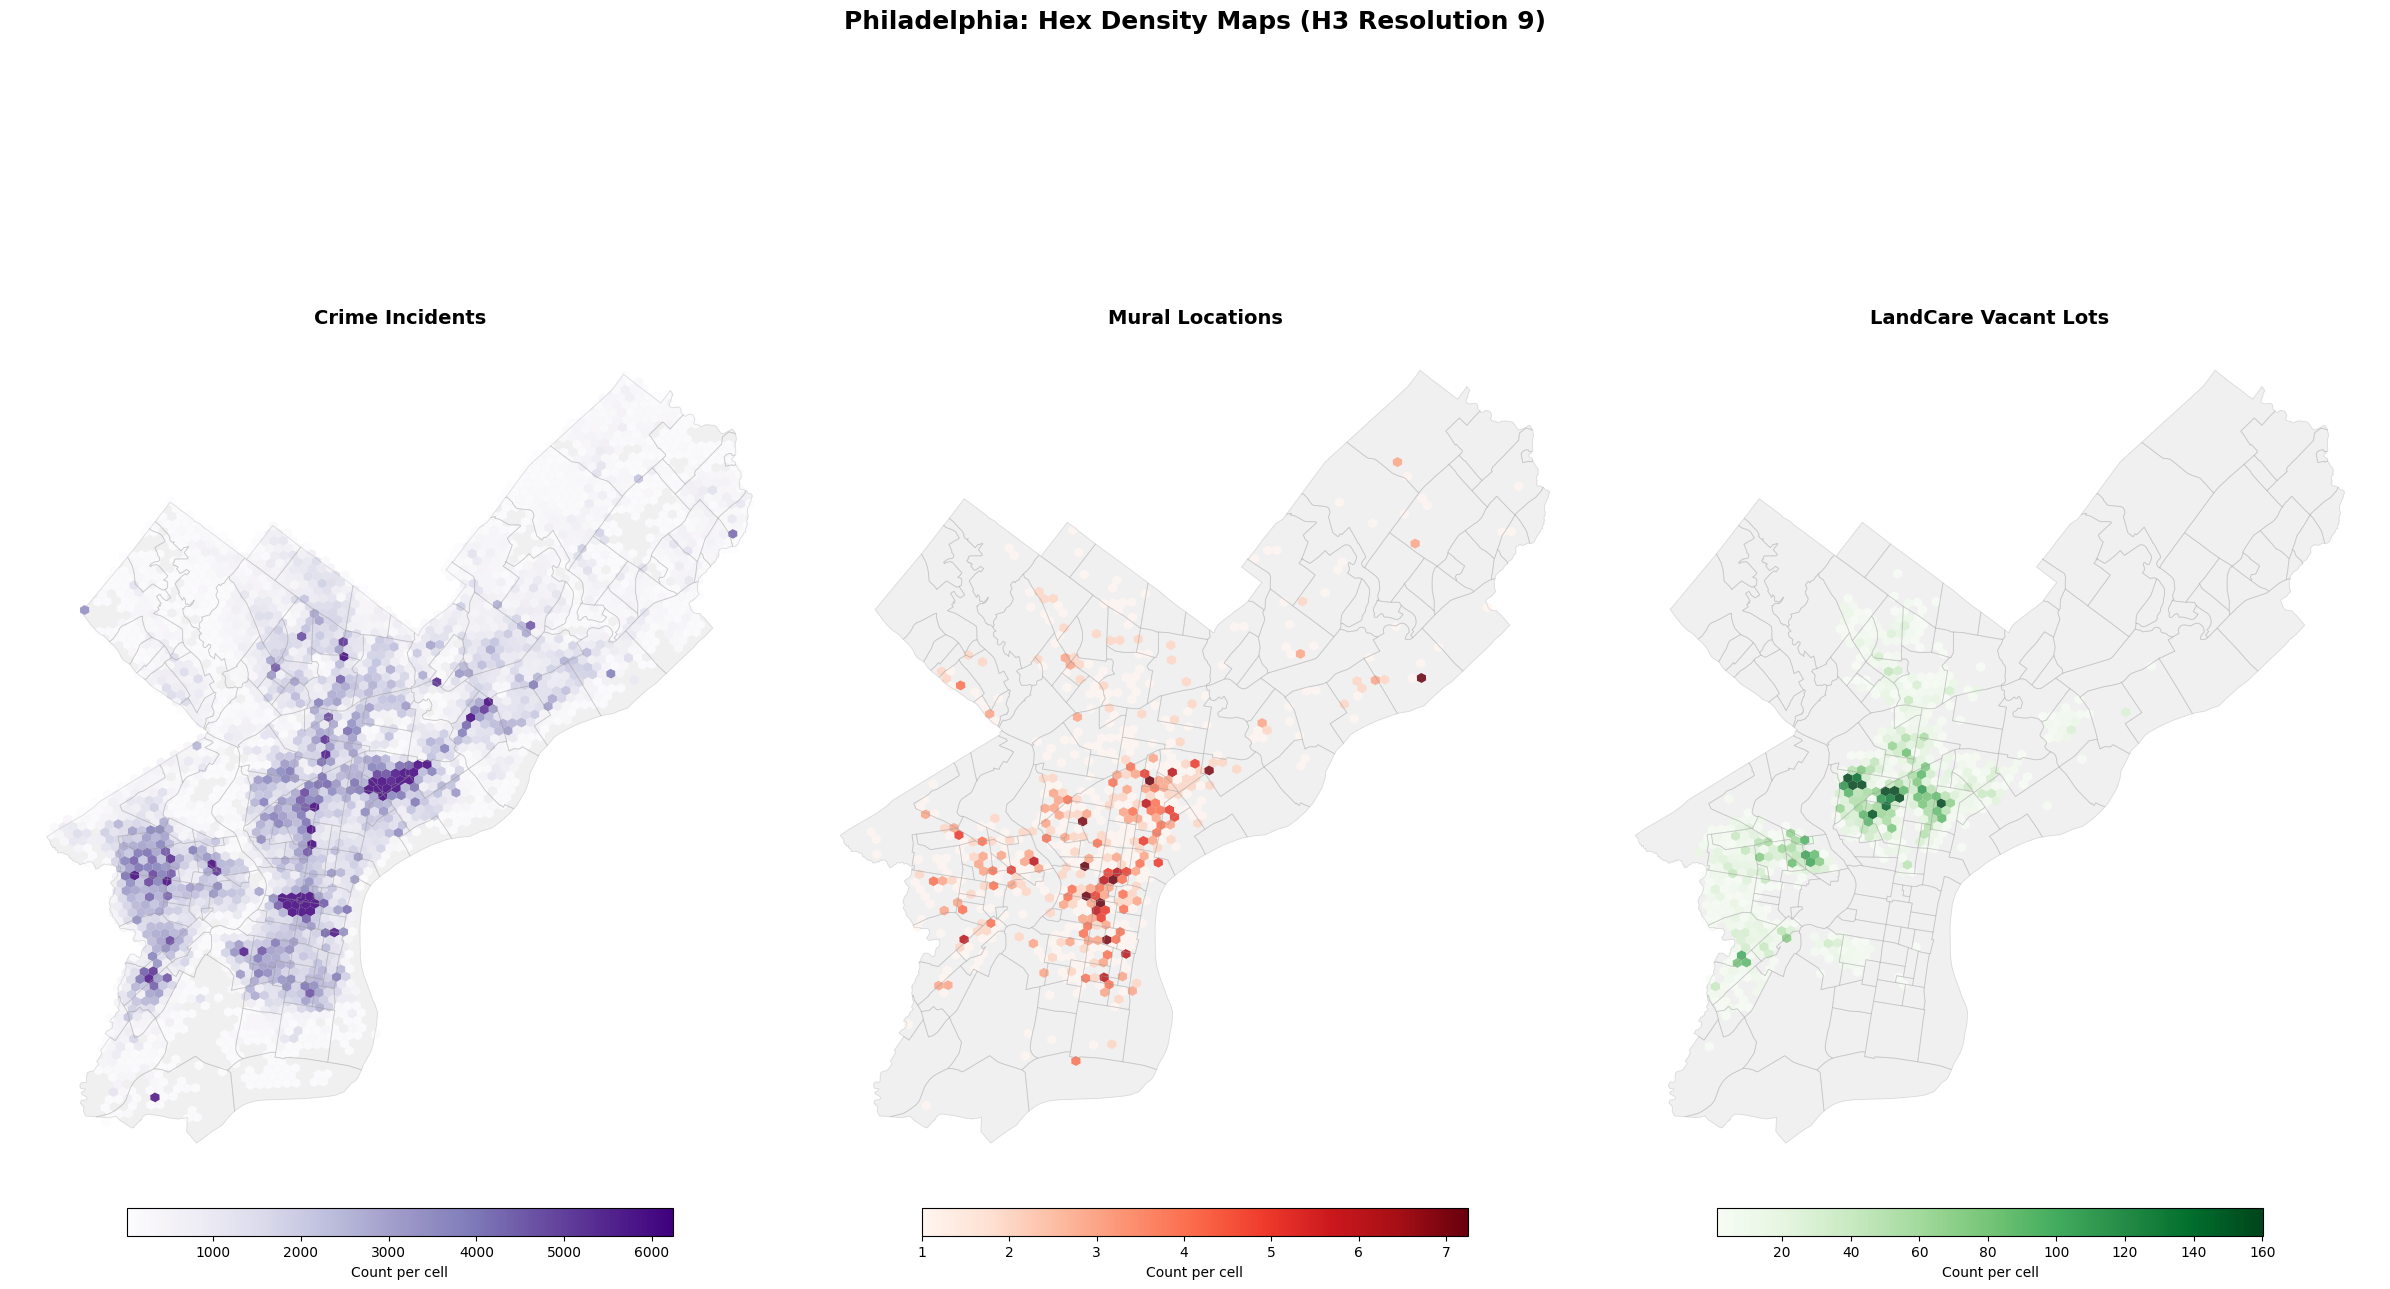

In [542]:
# Plot hex maps

fig, axes = plt.subplots(1, 3, figsize=(24, 14))

hex_layers = [
    (crime_hex,    'Crime Incidents',      'Purples'),
    (mural_hex,    'Mural Locations',      'Reds'),
    (landcare_hex, 'LandCare Vacant Lots', 'Greens'),
]

# Neighbourhood boundary outline only — no fill, no streets
nbhd_boundary = neighborhoods.copy()

for ax, (hex_gdf, title, cmap) in zip(axes, hex_layers):
    # Grey base
    nbhd_boundary.plot(ax=ax, color='#f0f0f0', edgecolor='none')

    # Hex layer
    hex_gdf.plot(
    ax=ax,
    column='count',
    cmap=cmap,
    vmin=hex_gdf['count'].quantile(0.1),  # bottom 10% sets the floor
    vmax=hex_gdf['count'].quantile(0.99),  # top 5% sets the ceiling
    legend=True,
    legend_kwds={
        'label'      : 'Count per cell',
        'orientation': 'horizontal',
        'shrink'     : 0.7,
        'pad'        : 0.02,
    },
    alpha=0.85,
    edgecolor='none',
)

    # Neighbourhood outlines on top — thin, white, semi-transparent
    nbhd_boundary.plot(
        ax=ax,
        color='none',
        edgecolor="#999999",
        linewidth=0.6,
        alpha=0.3,
    )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Philadelphia: Hex Density Maps (H3 Resolution 9)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/map_hex_density.png', dpi=150, bbox_inches='tight')
plt.show()

## Models

Four model variants are run per algorithm, each using different feature sets to isolate and compare various outcomes.

- **Model A** uses `mural_density` only, and is our baseline.  It isolates the mural effect and replicates cited literature.
- **Model B** uses `landcare_density`.  This is our Greenspace-only isolation.
- **Model C** uses `mural_density` and `landcare_density` combined.  Comparing A & B both separately and together is the novelty within this project.
- **Model D** uses `mural_density`, `landcare_density`, and `mural_x_landcare`.  This model tests for synergy; whether co-presence of both interventions produces non-additive effects.

Each model is run three times, once per response variable:
- `crime_rate_total` — overall safety signal
- `crime_rate_property` — CPTED theory suggests environmental improvements may differentially affect property vs. violent crime
- `crime_rate_violent` — less likely to respond to environmental cues

**Algorithms used:**
1. Negative Binomial Regression — baseline interpretable model for count/rate data
2. Random Forest Regression — captures non-linear relationships and feature interactions
3. Spatial Lag Regression — accounts for spatial autocorrelation between neighbouring areas
4. K-Means Clustering — unsupervised neighbourhood profiling

**Performance metrics by algorithm:**
- Negative Binomial Regression: Pseudo-R² and AIC
- Random Forest Regression: Cross-validated R² and RMSE
- Spatial Lag Regression: Pseudo-R² and residual Moran's I
- K-Means Clustering: Silhouette score and Davies-Bouldin score

**Note:** `ppr_site_density` was included as a feature in the matrix, but was found to be non-significant across all runs throughout all model results, so it is not discussed in this breakdown.

In [543]:
# Feature display labels and colours

feature_labels = {
    'mural_density'    : 'Mural Density',
    'landcare_density' : 'LandCare Density',
    'ppr_site_density' : 'PPR Site Density',
    'mural_x_landcare' : 'Mural × LandCare',
}

feature_colors = {
    'mural_density'    : '#e63946',
    'landcare_density' : '#2dc653',
    'ppr_site_density' : '#457b9d',
    'mural_x_landcare' : '#9b59b6',
}

### Method 1: Negative Binomial Regression

Negative binomial regression was used instead of standard linear regression because:
- crime counts can only be positive numbers
- the counts are overdispersed — the spread of values is far wider than standard regression expects 
This is the standard approach in criminological literature (see Branas et al., 2018).

We run all models against each of the three response variables, producing 12 regression results in total. 

Key outputs are:
- coefficients - the direction and magnitude of each feature's relationship with crime
- p-values - whether the relationship is significant or potentially just noise
- pseudo-R² — measures how much better the model fits the data compared to a model with no predictors at all

In [544]:
# Negative Binomial Regression setup

# Feature sets for each model
feature_sets = {
    'A': ['mural_density'],
    'B': ['landcare_density', 'ppr_site_density'],
    'C': ['mural_density', 'landcare_density', 'ppr_site_density'],
    'D': ['mural_density', 'landcare_density', 'ppr_site_density', 'mural_x_landcare'],
}

response_vars = ['crime_rate_total', 'crime_rate_property', 'crime_rate_violent']

response_titles = {
    'crime_rate_total'   : 'Total Crime Rate',
    'crime_rate_property': 'Property Crime Rate',
    'crime_rate_violent' : 'Violent Crime Rate',
}

In [545]:
# Negative Binomial Regression run

nb_results = {}

for response in response_vars:
    nb_results[response] = {}
    for model_name, features in feature_sets.items():

        X = sm.add_constant(feat_scaled[features])
        y = feat[response]  # raw rates for interpretable coefficients

        try:
            model = sm.NegativeBinomial(y, X).fit(disp=False)
            nb_results[response][model_name] = model
        except Exception as e:
            print(f"  Model {model_name} / {response} failed: {e}")

print("Negative Binomial models fitted:")
for response in response_vars:
    for model_name in feature_sets:
        if model_name in nb_results[response]:
            r = nb_results[response][model_name]
            print(f"  {response} | Model {model_name} — "
                  f"Pseudo-R²: {r.prsquared:.4f}  "
                  f"AIC: {r.aic:.1f}  "
                  f"converged: {r.mle_retvals['converged']}")

Negative Binomial models fitted:
  crime_rate_total | Model A — Pseudo-R²: 0.0152  AIC: 3302.7  converged: True
  crime_rate_total | Model B — Pseudo-R²: 0.0066  AIC: 3333.5  converged: True
  crime_rate_total | Model C — Pseudo-R²: 0.0198  AIC: 3291.1  converged: True
  crime_rate_total | Model D — Pseudo-R²: 0.0237  AIC: 3280.2  converged: True
  crime_rate_property | Model A — Pseudo-R²: 0.0216  AIC: 2997.1  converged: True
  crime_rate_property | Model B — Pseudo-R²: 0.0036  AIC: 3054.1  converged: True
  crime_rate_property | Model C — Pseudo-R²: 0.0232  AIC: 2996.3  converged: True
  crime_rate_property | Model D — Pseudo-R²: 0.0264  AIC: 2988.6  converged: True
  crime_rate_violent | Model A — Pseudo-R²: 0.0103  AIC: 2866.4  converged: True
  crime_rate_violent | Model B — Pseudo-R²: 0.0096  AIC: 2870.4  converged: True
  crime_rate_violent | Model C — Pseudo-R²: 0.0172  AIC: 2850.5  converged: True
  crime_rate_violent | Model D — Pseudo-R²: 0.0209  AIC: 2841.7  converged: True

In [546]:
# ── Negative Binomial results summary table ───────────────────────────────────

rows = []
for response in response_vars:
    for model_name, features in feature_sets.items():
        if model_name not in nb_results[response]:
            continue
        r = nb_results[response][model_name]
        for feature in features:
            coef  = r.params.get(feature, None)
            pval  = r.pvalues.get(feature, None)
            if coef is not None:
                rows.append({
                    'response'   : response,
                    'model'      : model_name,
                    'feature'    : feature,
                    'coef'       : round(coef, 4),
                    'p_value'    : round(pval, 4),
                    'significant': '✓' if pval < 0.05 else ''
                })

nb_summary = pd.DataFrame(rows)

print("Negative Binomial Regression — Coefficient Summary:")
print(nb_summary.to_string(index=False))

Negative Binomial Regression — Coefficient Summary:
           response model          feature    coef  p_value significant
   crime_rate_total     A    mural_density  0.5802   0.0000           ✓
   crime_rate_total     B landcare_density  0.2845   0.0010           ✓
   crime_rate_total     B ppr_site_density  0.2113   0.0060           ✓
   crime_rate_total     C    mural_density  0.4976   0.0000           ✓
   crime_rate_total     C landcare_density  0.2602   0.0010           ✓
   crime_rate_total     C ppr_site_density  0.1127   0.1397            
   crime_rate_total     D    mural_density  0.6122   0.0000           ✓
   crime_rate_total     D landcare_density  0.7916   0.0000           ✓
   crime_rate_total     D ppr_site_density  0.1345   0.0741            
   crime_rate_total     D mural_x_landcare -0.6008   0.0002           ✓
crime_rate_property     A    mural_density  0.5717   0.0000           ✓
crime_rate_property     B landcare_density  0.1271   0.0782            
crime_rate_p

In [547]:
# Pseudo-R² comparison across models

print("Pseudo-R² by model and response variable:")
print(f"{'':25} {'Model A':>10} {'Model B':>10} {'Model C':>10} {'Model D':>10}")
print("-" * 65)
for response in response_vars:
    vals = []
    for model_name in ['A', 'B', 'C', 'D']:
        if model_name in nb_results[response]:
            vals.append(f"{nb_results[response][model_name].prsquared:>10.4f}")
        else:
            vals.append(f"{'N/A':>10}")
    print(f"{response:25} {''.join(vals)}")

print()
print("Note: improvement from Model A→C tests additive effect of greenspace")
print("      improvement from Model C→D tests synergy (interaction term)")
print("      Model B < Model A across all responses — murals alone outpredict greenspace alone")

Pseudo-R² by model and response variable:
                             Model A    Model B    Model C    Model D
-----------------------------------------------------------------
crime_rate_total              0.0152    0.0066    0.0198    0.0237
crime_rate_property           0.0216    0.0036    0.0232    0.0264
crime_rate_violent            0.0103    0.0096    0.0172    0.0209

Note: improvement from Model A→C tests additive effect of greenspace
      improvement from Model C→D tests synergy (interaction term)
      Model B < Model A across all responses — murals alone outpredict greenspace alone


#### Key Findings

- `mural_density` is positively associated with crime rates across all models, which is consistent with **selection bias**.  Mural programs target high-crime neighbourhoods and create a known limitation of neighbourhood-level analysis.  This does not imply causation.
- The **interaction term** (`mural_x_landcare`) is negative and significant across all three response variables in Model D, suggesting a **synergistic suppression effect** in neighbourhoods where both interventions co-exist.
- Model D consistently produces the lowest AIC and highest pseudo-R², confirming that the combined + interaction model is the best fit.
- Pseudo-R² values (0.01–0.026) are modest but expected for environmental-only models without socioeconomic controls.
- `ppr_site_density` is generally not significant once mural and greening density are included, suggesting recreation sites add limited independent explanatory power at the neighbourhood level.

### Method 2: Random Forest Regression

Random Forest was used as a more flexible complement to Negative Binomial Regression because:
- it builds hundreds of decision trees and averages their predictions, reducing the risk of overfitting
- it captures non-linear relationships and feature interactions without requiring them to be specified in advance

We run all models against each of the three response variables, producing 12 regression results in total.

Key outputs are:
- R² — how much of the variation in crime rates the model explains, estimated using 5-fold cross-validation
- RMSE — the average size of the model's prediction errors, in the same units as the crime rate
- feature importances — which variables contribute most to prediction, expressed as a percentage of total model contribution

In [548]:
# Random Forest setup

# 5-fold cross-validation — robust given small sample (159 neighbourhoods)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_results     = {}   # stores CV scores
rf_models      = {}   # stores fitted models (on full data, for feature importance)
rf_importances = {}   # stores feature importance DataFrames

print("Random Forest setup:")
print(f"  Cross-validation : 5-fold")
print(f"  Sample size      : {len(feat_scaled)} neighbourhoods")
print(f"  Random state     : 42")
print(f"\nFeature sets:")
for model_name, features in feature_sets.items():
    print(f"  Model {model_name}: {features}")

Random Forest setup:
  Cross-validation : 5-fold
  Sample size      : 159 neighbourhoods
  Random state     : 42

Feature sets:
  Model A: ['mural_density']
  Model B: ['landcare_density', 'ppr_site_density']
  Model C: ['mural_density', 'landcare_density', 'ppr_site_density']
  Model D: ['mural_density', 'landcare_density', 'ppr_site_density', 'mural_x_landcare']


In [549]:
# Random Forest run

for response in response_vars:
    rf_results[response]     = {}
    rf_models[response]      = {}
    rf_importances[response] = {}

    for model_name, features in feature_sets.items():
        X = feat_scaled[features].values
        y = feat[response].values

        # 5-fold CV for R² and RMSE
        rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)

        cv_r2   = cross_val_score(rf, X, y, cv=kf, scoring='r2')
        cv_rmse = cross_val_score(rf, X, y, cv=kf,
                                  scoring='neg_root_mean_squared_error')

        rf_results[response][model_name] = {
            'r2_mean'  : cv_r2.mean(),
            'r2_std'   : cv_r2.std(),
            'rmse_mean': -cv_rmse.mean(),
            'rmse_std' : cv_rmse.std(),
        }

        # Fit on full dataset for feature importances
        rf.fit(X, y)
        rf_models[response][model_name] = rf
        rf_importances[response][model_name] = pd.DataFrame({
            'feature'   : features,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)

print("Random Forest — Cross-validated results (5-fold):")
print(f"\n{'':25} {'Model A':>12} {'Model B':>12} {'Model C':>12} {'Model D':>12}")
print("-" * 75)
for response in response_vars:
    r2_vals = []
    for model_name in ['A', 'B', 'C', 'D']:
        r = rf_results[response][model_name]
        r2_vals.append(f"{r['r2_mean']:>+8.4f} ± {r['r2_std']:.3f}")
    print(f"{response:25} {'  '.join(r2_vals)}")

Random Forest — Cross-validated results (5-fold):

                               Model A      Model B      Model C      Model D
---------------------------------------------------------------------------
crime_rate_total           +0.3574 ± 0.205   +0.2189 ± 0.106   +0.4251 ± 0.309   +0.4221 ± 0.300
crime_rate_property        +0.0741 ± 0.851   +0.0390 ± 0.093   +0.0095 ± 0.774   -0.0105 ± 0.800
crime_rate_violent         +0.2716 ± 0.172   +0.3720 ± 0.074   +0.4598 ± 0.234   +0.4488 ± 0.239


In [550]:
# Random Forest — RMSE comparison table

print("Random Forest — RMSE by model and response variable:")
print(f"\n{'':25} {'Model A':>14} {'Model B':>14} {'Model C':>14} {'Model D':>14}")
print("-" * 82)
for response in response_vars:
    rmse_vals = []
    for model_name in ['A', 'B', 'C', 'D']:
        r = rf_results[response][model_name]
        rmse_vals.append(f"{r['rmse_mean']:>10.1f} ± {r['rmse_std']:.1f}")
    print(f"{response:25} {'  '.join(rmse_vals)}")

Random Forest — RMSE by model and response variable:

                                 Model A        Model B        Model C        Model D
----------------------------------------------------------------------------------
crime_rate_total              8885.9 ± 946.1     10284.9 ± 2601.0      8113.9 ± 779.7      8165.4 ± 779.8
crime_rate_property           3725.3 ± 1104.4      4520.3 ± 1510.9      3698.9 ± 373.9      3727.6 ± 406.9
crime_rate_violent            2241.0 ± 291.9      2109.3 ± 332.6      1864.2 ± 108.6      1886.3 ± 114.7


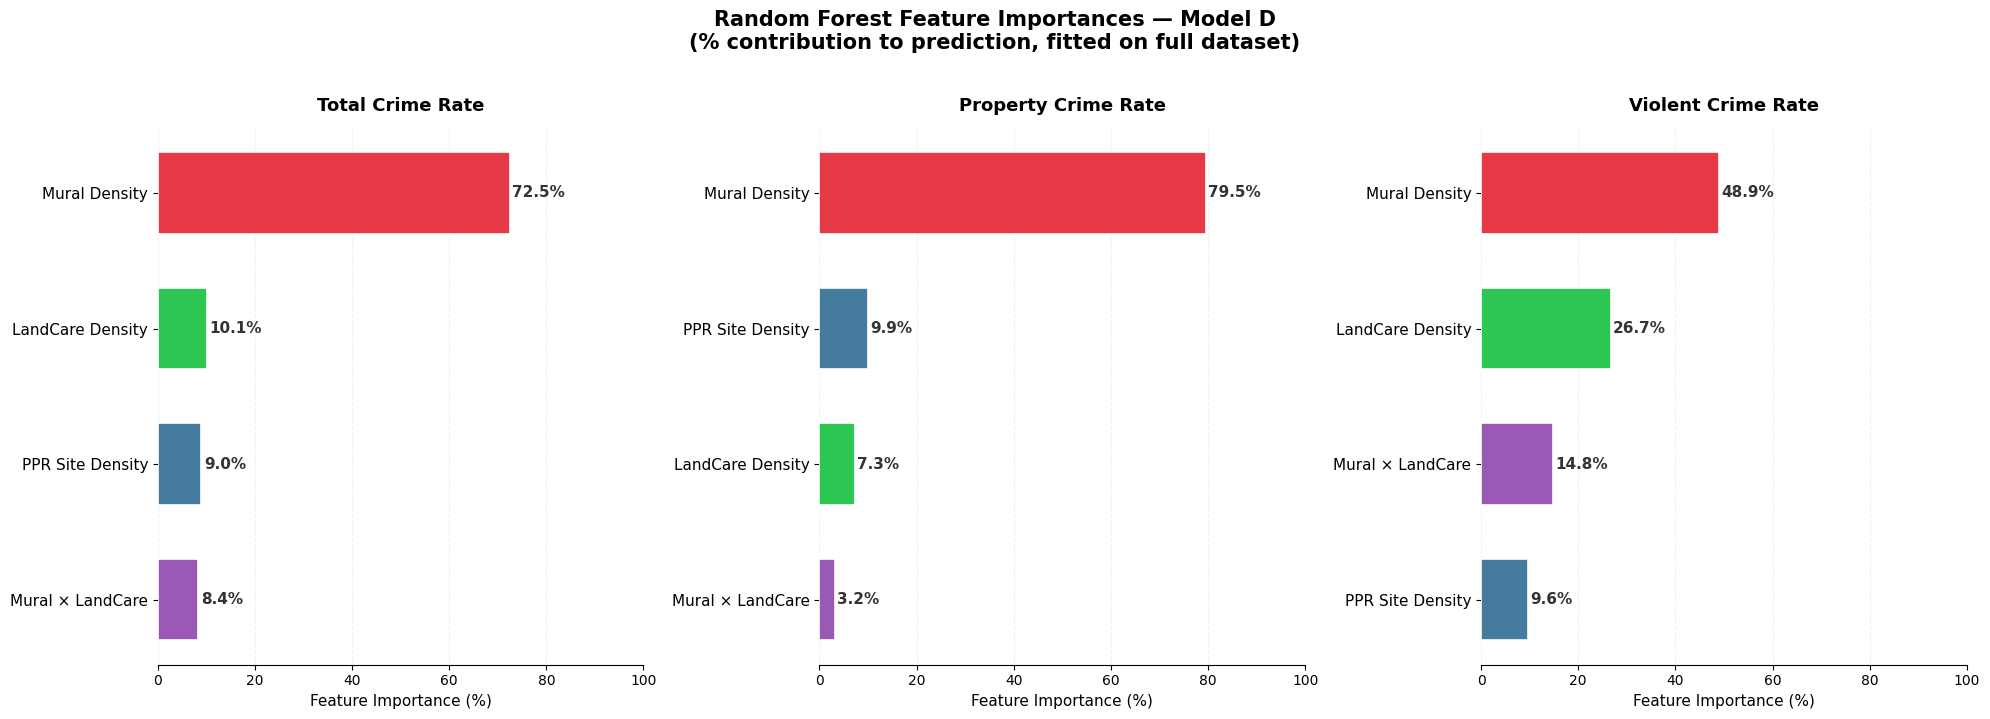

In [551]:
# Random Forest Feature Importances

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

response_labels = {
    'crime_rate_total'   : 'Total Crime Rate',
    'crime_rate_property': 'Property Crime Rate',
    'crime_rate_violent' : 'Violent Crime Rate',
}

for ax, response in zip(axes, response_vars):
    imp = rf_importances[response]['D'].copy()
    imp['label'] = imp['feature'].map(feature_labels)
    imp['color'] = imp['feature'].map(feature_colors)
    imp = imp.sort_values('importance', ascending=True)

    bars = ax.barh(
        imp['label'],
        imp['importance'] * 100,
        color=imp['color'],
        edgecolor='white',
        linewidth=1.2,
        height=0.6,
    )

    # Value labels on bars
    for bar, val in zip(bars, imp['importance'] * 100):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', ha='left',
            fontsize=11, fontweight='bold',
            color='#333333'
        )

    ax.set_xlim(0, 100)
    ax.set_xlabel('Feature Importance (%)', fontsize=11)
    ax.set_title(response_labels[response], fontsize=13, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=10)
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle(
    'Random Forest Feature Importances — Model D\n(% contribution to prediction, fitted on full dataset)',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/viz_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Random Forest Regression — Key Findings

- Model C (combined features, no interaction) performs best or equal to Model D for most response variables — Random Forest captures feature interactions implicitly through tree structure, making the explicit `mural_x_landcare` term less necessary than in the linear NB model.
- `crime_rate_property` is largely unpredictable from environmental features alone (R²≈0, high variance across folds) — property crime appears driven by factors outside this model's scope, such as commercial density or transit access.
- `mural_density` dominates feature importance across all response variables, consistent with NB results — again reflecting programme placement in high-crime areas rather than a causal relationship.
- `mural_x_landcare` ranks third for violent crime prediction (14.8% importance), suggesting the synergy effect is most pronounced for violent rather than property crime — a theoretically interesting result worth discussing.
- High standard deviations in cross-validation reflect the small sample size (159 neighbourhoods). Results should be interpreted with appropriate caution.

### Method 3: Spatial Lag Regression

Spatial Lag Regression was used because standard regression assumes all observations are independent, but neighbourhoods are not:
- high crime areas tend to be adjacent to other high crime areas
- mural programs and greening parcels cluster geographically
- ignoring this spatial structure violates OLS assumptions and produces biased estimates

We first test for spatial autocorrelation using Moran's I, then run all models against each of the three response variables, producing 12 regression results in total.

Key outputs are:
- coefficients — the direction and magnitude of each feature's relationship with crime, after controlling for spatial structure
- p-values — whether the relationship is significant or potentially just noise
- ρ (rho) — the spatial lag parameter, measuring how much of a neighbourhood's crime rate is explained by its neighbors' crime rates
- residual Moran's I — confirms whether the spatial structure was successfully absorbed by the model

In [552]:
# Spatial Lag Regression setup

# Build spatial weights matrix — Queen contiguity
# (neighbourhoods sharing any border or corner are considered neighbours)
w = Queen.from_dataframe(neighborhoods.merge(
    feat[['NAME']], on='NAME', how='inner'
).reset_index(drop=True))

# Row-standardise weights (each row sums to 1)
w.transform = 'r'

print(f"Spatial weights matrix:")
print(f"  Observations     : {w.n}")
print(f"  Mean neighbours  : {w.mean_neighbors:.2f}")
print(f"  Min neighbours   : {w.min_neighbors}")
print(f"  Max neighbours   : {w.max_neighbors}")
print(f"  Pct nonzero      : {w.pct_nonzero:.2f}%")

('WARNING: ', 126, ' is an island (no neighbors)')
('WARNING: ', 148, ' is an island (no neighbors)')
Spatial weights matrix:
  Observations     : 159
  Mean neighbours  : 4.69
  Min neighbours   : 0
  Max neighbours   : 10
  Pct nonzero      : 2.95%


In [553]:
# Identify islands and fix with KNN fallback

# Identify the island neighbourhoods
nbhd_for_weights = neighborhoods.merge(
    feat[['NAME']], on='NAME', how='inner'
).reset_index(drop=True)

print("Island neighbourhoods (no Queen contiguity neighbours):")
for idx in [126, 148]:
    print(f"  Index {idx}: {nbhd_for_weights.loc[idx, 'NAME']}")

# Fix using KNN to assign at least 1 neighbour to islands
# Build KNN weights with k=1 as fallback for islands only
knn1 = KNN.from_dataframe(nbhd_for_weights, k=1)

# Union Queen + KNN so islands get at least one neighbour
# while all other neighbourhoods keep their Queen neighbours
w_fixed = w_union(w, knn1)
w_fixed.transform = 'r'

print(f"\nFixed spatial weights matrix:")
print(f"  Observations     : {w_fixed.n}")
print(f"  Mean neighbours  : {w_fixed.mean_neighbors:.2f}")
print(f"  Min neighbours   : {w_fixed.min_neighbors}")
print(f"  Max neighbours   : {w_fixed.max_neighbors}")
print(f"  Islands remaining: {sum(1 for i in range(w_fixed.n) if len(w_fixed.neighbors[i]) == 0)}")

Island neighbourhoods (no Queen contiguity neighbours):
  Index 126: POWELTON
  Index 148: NAVY_YARD

Fixed spatial weights matrix:
  Observations     : 159
  Mean neighbours  : 4.84
  Min neighbours   : 1
  Max neighbours   : 10
  Islands remaining: 0


In [554]:
# Moran's I — test for spatial autocorrelation in response variables

print("Moran's I — Spatial Autocorrelation Test:")
print(f"{'':25} {'Moran I':>10} {'p-value':>10} {'Interpretation':>20}")
print("-" * 70)

for response in response_vars:
    y = feat[response].values
    mi = esda.Moran(y, w_fixed)
    sig = '✓ significant' if mi.p_sim < 0.05 else 'not significant'
    print(f"{response:25} {mi.I:>10.4f} {mi.p_sim:>10.4f} {sig:>20}")

Moran's I — Spatial Autocorrelation Test:
                             Moran I    p-value       Interpretation
----------------------------------------------------------------------
crime_rate_total              0.5606     0.0010        ✓ significant
crime_rate_property           0.5704     0.0010        ✓ significant
crime_rate_violent            0.5556     0.0010        ✓ significant


In [555]:
# Spatial Lag Regression run

sl_results = {}

# Align neighborhoods with feat for consistent ordering
nbhd_aligned = neighborhoods.merge(
    feat[['NAME']], on='NAME', how='inner'
).reset_index(drop=True)

for response in response_vars:
    sl_results[response] = {}
    y = feat[response].values.reshape(-1, 1)

    for model_name, features in feature_sets.items():
        X = feat_scaled[features].values

        try:
            model = ML_Lag(y, X, w_fixed,
                          name_y=response,
                          name_x=features,
                          name_ds='Philadelphia Neighbourhoods')
            sl_results[response][model_name] = model
        except Exception as e:
            print(f"  Model {model_name} / {response} failed: {e}")

print("Spatial Lag models fitted:")
print(f"\n{'':25} {'Model A':>10} {'Model B':>10} {'Model C':>10} {'Model D':>10}")
print("-" * 65)
for response in response_vars:
    r2_vals = []
    for model_name in ['A', 'B', 'C', 'D']:
        if model_name in sl_results[response]:
            r2_vals.append(f"{sl_results[response][model_name].pr2:>10.4f}")
        else:
            r2_vals.append(f"{'N/A':>10}")
    print(f"{response:25} {''.join(r2_vals)}")

ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
ML_Lag
Spatial Lag models fitted:

                             Model A    Model B    Model C    Model D
-----------------------------------------------------------------
crime_rate_total              0.5821    0.5810    0.6055    0.6180
crime_rate_property           0.5826    0.5570    0.5877    0.5948
crime_rate_violent            0.5824    0.6170    0.6306    0.6373


In [556]:
# Spatial Lag results — rho and key coefficients

print("Spatial Lag Parameter (ρ) — how much crime spills over from neighbours:")
print(f"\n{'':25} {'Model A':>10} {'Model B':>10} {'Model C':>10} {'Model D':>10}")
print("-" * 65)
for response in response_vars:
    rho_vals = []
    for model_name in ['A', 'B', 'C', 'D']:
        if model_name in sl_results[response]:
            r = sl_results[response][model_name]
            rho_vals.append(f"{r.rho:>10.4f}")
        else:
            rho_vals.append(f"{'N/A':>10}")
    print(f"{response:25} {''.join(rho_vals)}")

print()
print("Coefficient summary (Model D — full feature set):")
print(f"\n{'':25} {'':>20} {'crime_rate_total':>18} {'crime_rate_property':>20} {'crime_rate_violent':>18}")
print("-" * 85)

sl_feature_labels = feature_sets['D'] + ['W_y (spatial lag)']

for i, label in enumerate(sl_feature_labels):
    vals = []
    for response in response_vars:
        if 'D' in sl_results[response]:
            r = sl_results[response]['D']
            # coefficients: betas first, then rho
            if i < len(feature_sets['D']):
                coef = r.betas[i+1][0]  # +1 to skip constant
                pval = r.z_stat[i+1][1]
            else:
                coef = r.rho
                pval = r.z_stat[-1][1]
            sig = '✓' if pval < 0.05 else ''
            vals.append(f"{coef:>+8.4f}{sig:>3}")
        else:
            vals.append(f"{'N/A':>11}")
    print(f"{label:25} {''.join(f'{v:>18}' for v in vals)}")

Spatial Lag Parameter (ρ) — how much crime spills over from neighbours:

                             Model A    Model B    Model C    Model D
-----------------------------------------------------------------
crime_rate_total              0.5999    0.7086    0.5580    0.5217
crime_rate_property           0.5436    0.7315    0.5468    0.5111
crime_rate_violent            0.6895    0.6774    0.6034    0.5719

Coefficient summary (Model D — full feature set):

                                                 crime_rate_total  crime_rate_property crime_rate_violent
-------------------------------------------------------------------------------------
mural_density                  +4420.4341  ✓     +2143.1532  ✓      +675.4904  ✓
landcare_density               +5856.8718  ✓     +1494.9295  ✓     +1453.6916  ✓
ppr_site_density                 +11.5037         -246.8936         +148.3263   
mural_x_landcare               -4095.3171  ✓     -1428.3625  ✓      -762.9537  ✓
W_y (spatial lag)     

In [557]:
# Moran's I on residuals — did spatial lag model fix autocorrelation?

print("Moran's I on Spatial Lag residuals (Model D):")
print("(should be close to 0 and non-significant if model addressed autocorrelation)")
print()
print(f"{'':25} {'Moran I':>10} {'p-value':>10} {'Resolved?':>12}")
print("-" * 60)

for response in response_vars:
    if 'D' in sl_results[response]:
        residuals = sl_results[response]['D'].u
        mi_resid = esda.Moran(residuals.flatten(), w_fixed)
        resolved = '✓ yes' if mi_resid.p_sim >= 0.05 else '✗ no'
        print(f"{response:25} {mi_resid.I:>10.4f} {mi_resid.p_sim:>10.4f} {resolved:>12}")

Moran's I on Spatial Lag residuals (Model D):
(should be close to 0 and non-significant if model addressed autocorrelation)

                             Moran I    p-value    Resolved?
------------------------------------------------------------
crime_rate_total             -0.0229     0.3680        ✓ yes
crime_rate_property          -0.0401     0.2390        ✓ yes
crime_rate_violent            0.0200     0.2800        ✓ yes


#### Spatial Lag Regression — Key Findings

- **Moran's I = 0.56** for all three response variables (p=0.001) — strong positive spatial autocorrelation confirmed. High-crime neighborhoods cluster geographically, validating the use of spatial regression over standard OLS.
- **Pseudo-R² improves dramatically** (0.58–0.64) compared to NB (~0.02) and RF (~0.35–0.46) once spatial structure is accounted for, confirming that neighborhood crime is strongly shaped by its spatial context.
- **ρ (rho) = 0.52–0.73** across models — between half and three quarters of a neighborhood's crime rate is explained by adjacent neighborhoods' rates alone.
- **`mural_x_landcare` remains negative and significant** in Model D across all response variables even after controlling for spatial autocorrelation.  The synergy finding is robust and not an artefact of spatial clustering.
- **Residual Moran's I is non-significant** for all three response variables (p>0.25), confirming the spatial lag specification successfully resolved spatial autocorrelation in the residuals.
- **`ppr_site_density` is consistently non-significant** across all three methods — recreation sites do not add independent explanatory power at the neighbourhood level.
- Model D consistently outperforms Models A–C on pseudo-R², confirming the interaction term adds value even in a spatially-aware model.

### Method 4: K-Means Clustering

K-Means clustering was used as an unsupervised complement to the regression methods because:
- it groups neighbourhoods into distinct profiles without using crime as a target variable
- unlike regression, it makes no assumptions about directionality (it simply finds natural groupings in the data)
- the resulting clusters can then be examined for crime rate differences, revealing whether programs are deployed in already safe areas or genuinely high-need areas

We cluster using the standardised intervention density features only (`mural_density`, `landcare_density`, `ppr_site_density`), then examine how crime rates vary across the resulting clusters.

Key outputs are:
- cluster assignments — which neighborhood belongs to which group
- cluster profiles — the mean feature values and crime rates for each group
- silhouette score — measures how well-separated the clusters are (higher is better)
- Davies-Bouldin score — measures how compact and distinct the clusters are (lower is better)

In [558]:
# K-Means setup — find optimal number of clusters

# Features used for clustering — intervention densities only, not crime
cluster_features = ['mural_density', 'landcare_density', 'ppr_site_density']
X_cluster = feat_scaled[cluster_features].values

# Test k=2 through k=8 using elbow method and silhouette score
k_range    = range(2, 9)
inertias   = []
silhouettes = []
db_scores  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))
    db_scores.append(davies_bouldin_score(X_cluster, labels))

print("K-Means cluster evaluation:")
print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 46)
for k, inertia, sil, db in zip(k_range, inertias, silhouettes, db_scores):
    print(f"{k:>4} {inertia:>12.1f} {sil:>12.4f} {db:>16.4f}")

print()
print("Silhouette: higher is better (max 1.0)")
print("Davies-Bouldin: lower is better (min 0.0)")

K-Means cluster evaluation:

   k      Inertia   Silhouette   Davies-Bouldin
----------------------------------------------
   2        310.9       0.5401           1.2191
   3        207.9       0.6002           0.8709
   4        164.5       0.5289           0.8738
   5        131.6       0.4534           0.9420
   6        111.3       0.4462           0.8942
   7         95.4       0.4599           0.8039
   8         84.2       0.4233           0.8512

Silhouette: higher is better (max 1.0)
Davies-Bouldin: lower is better (min 0.0)


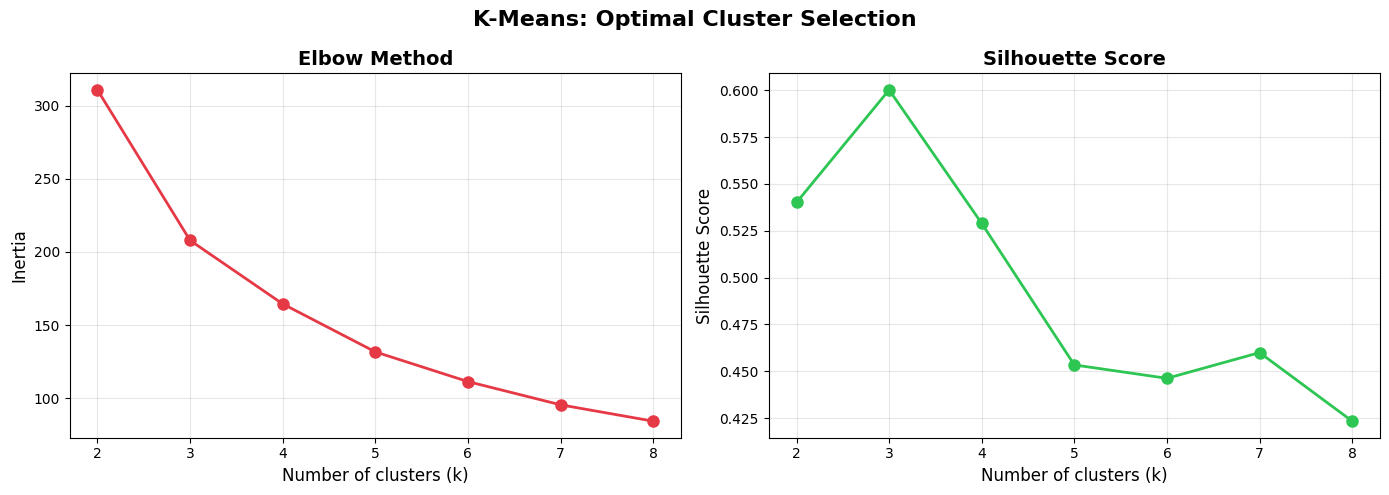

In [559]:
# Elbow and silhouette plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'o-', color='#e63946', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, 'o-', color='#2dc653', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means: Optimal Cluster Selection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/kmeans_cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [560]:
# Fit final K-Means model with k=3

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
feat['cluster'] = km_final.fit_predict(X_cluster)

print("Cluster assignments:")
print(feat['cluster'].value_counts().sort_index().to_string())

print("\nCluster centroids (standardised feature space):")
centroids = pd.DataFrame(
    km_final.cluster_centers_,
    columns=cluster_features
)
centroids.index.name = 'cluster'
print(centroids.round(3).to_string())

print("\nCluster profiles (raw feature means):")
profile = feat.groupby('cluster')[
    cluster_features + ['crime_rate_total', 'crime_rate_property', 'crime_rate_violent']
].mean().round(2)
print(profile.to_string())

Cluster assignments:
cluster
0    128
1     11
2     20

Cluster centroids (standardised feature space):
         mural_density  landcare_density  ppr_site_density
cluster                                                   
0               -0.313            -0.229            -0.296
1                0.693             3.144             0.032
2                1.625            -0.263             1.876

Cluster profiles (raw feature means):
         mural_density  landcare_density  ppr_site_density  crime_rate_total  crime_rate_property  crime_rate_violent
cluster                                                                                                              
0                 3.54             25.33              0.39          11336.33              4577.89             2728.70
1                12.46            489.67              0.69          25167.57              8306.08             6787.00
2                20.72             20.73              2.41          22892.49             

In [561]:
# Label clusters based on profiles

# We'll assign labels after seeing the profiles — placeholder until output
cluster_labels = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
}

print("Neighbourhoods per cluster:")
for cluster_id in sorted(feat['cluster'].unique()):
    names = feat[feat['cluster'] == cluster_id]['NAME'].tolist()
    print(f"\n  Cluster {cluster_id} ({len(names)} neighbourhoods):")
    for name in sorted(names):
        print(f"    {name}")

Neighbourhoods per cluster:

  Cluster 0 (128 neighbourhoods):
    ACADEMY_GARDENS
    AIRPORT
    ALLEGHENY_WEST
    ANDORRA
    ASTON_WOODBRIDGE
    BARTRAM_VILLAGE
    BLUE_BELL_HILL
    BRIDESBURG
    BURHOLME
    BUSTLETON
    BYBERRY
    CARROLL_PARK
    CEDARBROOK
    CEDAR_PARK
    CHESTNUT_HILL
    CHINATOWN
    COBBS_CREEK
    CRESCENTVILLE
    CRESTMONT_FARMS
    DEARNLEY_PARK
    EASTWICK
    EAST_FALLS
    EAST_KENSINGTON
    EAST_OAK_LANE
    EAST_PARK
    ELMWOOD
    FAIRMOUNT
    FELTONVILLE
    FERN_ROCK
    FISHTOWN
    FOX_CHASE
    FRANCISVILLE
    FRANKFORD
    FRANKLINVILLE
    FRANKLIN_MILLS
    GARDEN_COURT
    GERMANTOWN_EAST
    GERMANTOWN_MORTON
    GERMANTOWN_PENN_KNOX
    GERMANTOWN_SOUTHWEST
    GERMANTOWN_WESTSIDE
    GERMANTOWN_WEST_CENT
    GERMANY_HILL
    GIRARD_ESTATES
    GLENWOOD
    GRADUATE_HOSPITAL
    GRAYS_FERRY
    HADDINGTON
    HARROWGATE
    HOLMESBURG
    HUNTING_PARK
    INDUSTRIAL
    JUNIATA_PARK
    KINGSESSING
    LAWNDALE
    LEXING

In [562]:
# ── Assign meaningful cluster labels ─────────────────────────────────────────

cluster_labels = {
    0: 'Low Intervention',
    1: 'High LandCare / High Need',
    2: 'High Mural / High Density',
}

feat['cluster_label'] = feat['cluster'].map(cluster_labels)

print("Cluster labels assigned:")
print(feat['cluster_label'].value_counts().to_string())

print("\nCluster profiles with labels:")
profile_labelled = feat.groupby('cluster_label')[
    cluster_features + ['crime_rate_total', 'crime_rate_property', 'crime_rate_violent']
].mean().round(2)
print(profile_labelled.to_string())

Cluster labels assigned:
cluster_label
Low Intervention             128
High Mural / High Density     20
High LandCare / High Need     11

Cluster profiles with labels:
                           mural_density  landcare_density  ppr_site_density  crime_rate_total  crime_rate_property  crime_rate_violent
cluster_label                                                                                                                          
High LandCare / High Need          12.46            489.67              0.69          25167.57              8306.08             6787.00
High Mural / High Density          20.72             20.73              2.41          22892.49             10626.60             4699.87
Low Intervention                    3.54             25.33              0.39          11336.33              4577.89             2728.70


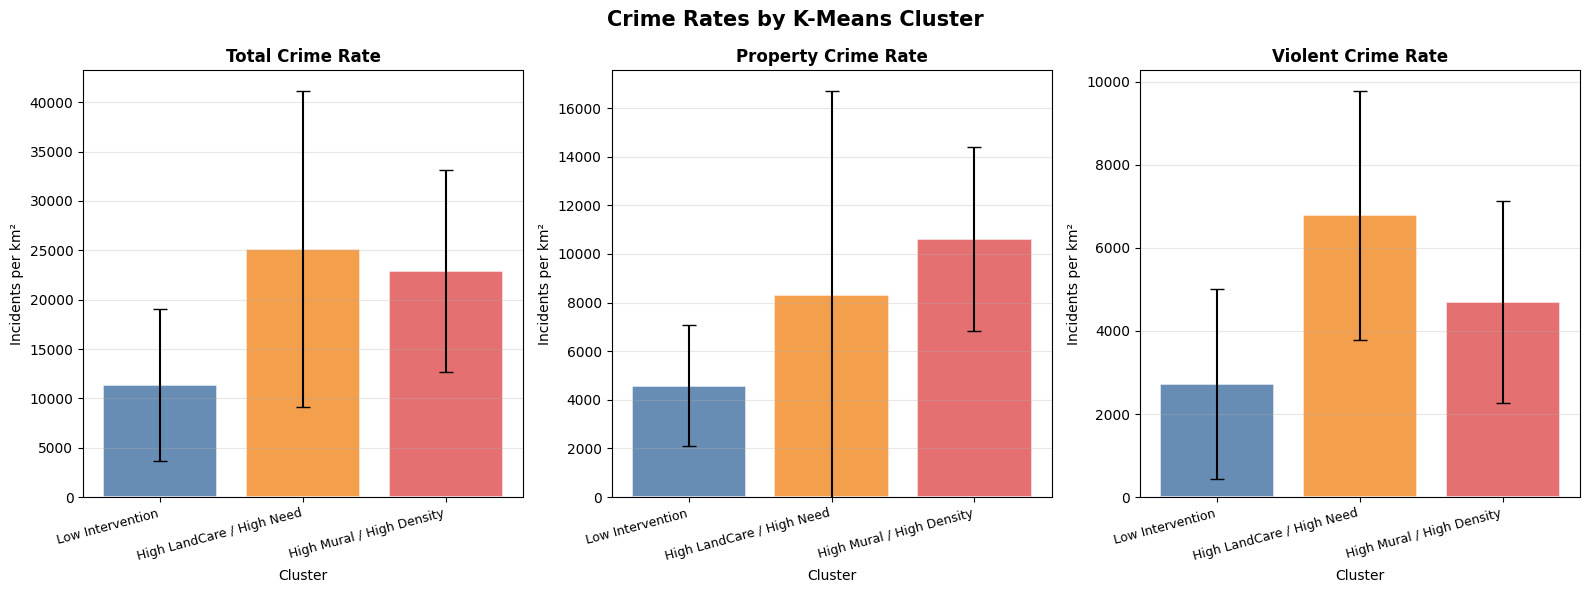

In [563]:
# Cluster crime rate comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

crime_plot_cols = [
    ('crime_rate_total',    'Total Crime Rate'),
    ('crime_rate_property', 'Property Crime Rate'),
    ('crime_rate_violent',  'Violent Crime Rate'),
]

colors = ['#4e79a7', '#f28e2b', '#e15759']

for ax, (col, title) in zip(axes, crime_plot_cols):
    cluster_means = feat.groupby('cluster_label')[col].mean().reindex([
    'Low Intervention',
    'High LandCare / High Need', 
    'High Mural / High Density'
    ])
    cluster_stds  = feat.groupby('cluster_label')[col].std()

    bars = ax.bar(
        cluster_means.index,  # uses label names directly
        cluster_means.values,
        yerr=cluster_stds.values,
        color=colors,
        edgecolor='white',
        linewidth=1.2,
        capsize=5,
        alpha=0.85,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Incidents per km²', fontsize=10)
    ax.set_xlabel('Cluster', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)
    ax.set_ylim(bottom=0)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Crime Rates by K-Means Cluster', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/kmeans_crime_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

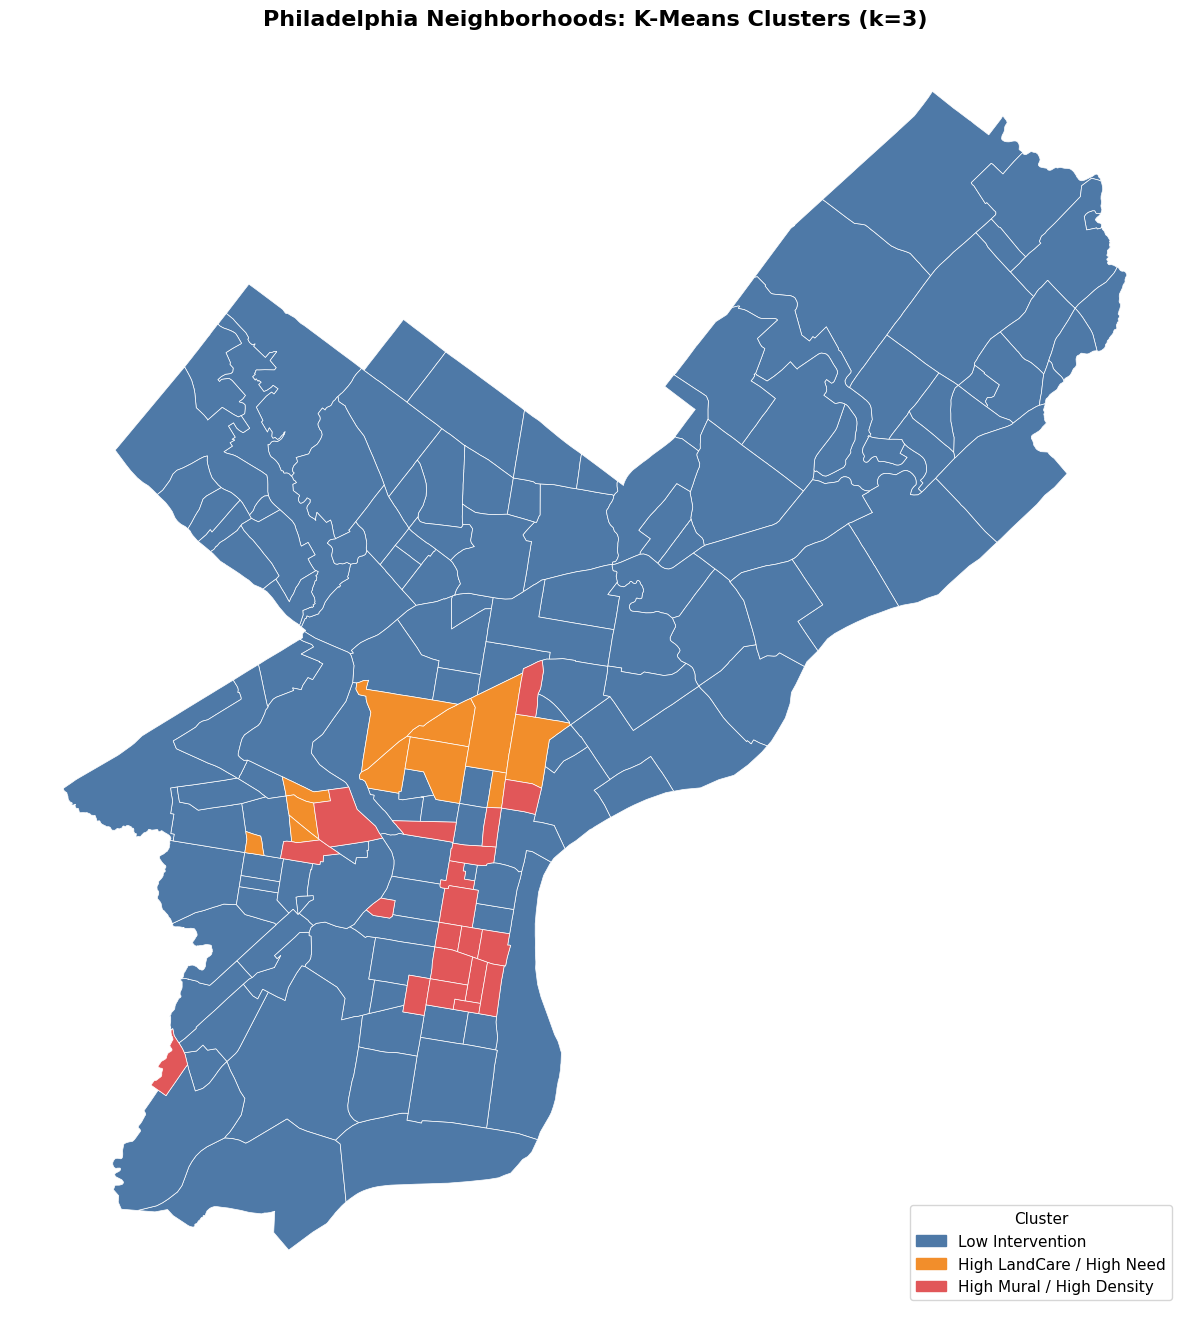

In [564]:
# Update cluster map with meaningful labels

neighborhoods_cluster = neighborhoods.merge(
    feat[['NAME', 'cluster', 'cluster_label']], on='NAME', how='left'
)

fig, ax = plt.subplots(figsize=(12, 14))

cluster_colors = {
    'Low Intervention'         : '#4e79a7',
    'High LandCare / High Need': '#f28e2b',
    'High Mural / High Density': '#e15759',
}

for label, color in cluster_colors.items():
    subset = neighborhoods_cluster[neighborhoods_cluster['cluster_label'] == label]
    subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)

# Build legend manually — bypasses geopandas label registration issue
legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in cluster_colors.items()
]
ax.legend(
    handles=legend_patches,
    loc='lower right',
    fontsize=11,
    title='Cluster',
    title_fontsize=11
)

ax.set_title('Philadelphia Neighborhoods: K-Means Clusters (k=3)',
             fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/map_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Method 5: Difference-in-Differences (Before/After Panel Analysis)

Methods 1–4 established where interventions and crime are concentrated, how crime spreads spatially, and what neighborhood profiles exist. However, none of those methods can answer the most important question: **did crime actually decrease after a mural was added or a vacant lot was greened?**

Difference-in-Differences (DiD) was used to answer this because:
- it compares crime rate changes in treated neighborhoods against untreated neighborhoods over the same period
- by differencing out time trends that affect all neighborhoods equally, it isolates the intervention effect from confounding factors
- it is the closest we can get to a causal answer without a randomised controlled trial

The design is as follows:
- **Treatment event** — the year a neighborhood received its first mural or first greened parcel
- **Control group** — neighborhoods that received no intervention during the study window
- **Estimator** — two-way fixed effects (neighborhood + year), absorbing time-invariant neighborhood characteristics and city-wide year trends
- **Window** — 5 years before and 5 years after the treatment event, as shown in the event study plots

We run three separate DiD analyses — mural only, greening only, and combined — against each of the three response variables.

Key outputs are:
- DiD coefficient — the estimated crime reduction attributable to the intervention (negative = crime fell)
- p-value — whether the reduction is statistically significant or potentially just noise
- event study plots — visual representation of crime trajectories before and after treatment for treated vs. control neighborhoods

In [565]:
# Build neighbourhood-year panel

# Aggregate crime to neighbourhood × year level
crime_panel = (
    crime_joined
    .merge(crime_df[['dispatch_date']]
           .assign(year=pd.to_datetime(crime_df['dispatch_date']).dt.year),
           left_index=True, right_index=True)
    [['NAME', 'year', 'crime_category']]
)

# Total crimes per neighbourhood per year
total_panel = (crime_panel
               .groupby(['NAME', 'year'])
               .size()
               .reset_index(name='crime_count_total'))

# Property crimes per neighbourhood per year
property_panel = (crime_panel[crime_panel['crime_category'] == 'property']
                  .groupby(['NAME', 'year'])
                  .size()
                  .reset_index(name='crime_count_property'))

# Violent crimes per neighbourhood per year
violent_panel = (crime_panel[crime_panel['crime_category'] == 'violent']
                 .groupby(['NAME', 'year'])
                 .size()
                 .reset_index(name='crime_count_violent'))

# Merge into single panel
panel = (total_panel
         .merge(property_panel, on=['NAME', 'year'], how='left')
         .merge(violent_panel,  on=['NAME', 'year'], how='left')
         .fillna(0))

# Add neighbourhood area for rate calculation
panel = panel.merge(feat[['NAME', 'area_km2']], on='NAME', how='left')

# Compute rates per km²
panel['crime_rate_total']    = panel['crime_count_total']    / panel['area_km2']
panel['crime_rate_property'] = panel['crime_count_property'] / panel['area_km2']
panel['crime_rate_violent']  = panel['crime_count_violent']  / panel['area_km2']

print(f"Panel shape         : {panel.shape}")
print(f"Neighbourhoods      : {panel['NAME'].nunique()}")
print(f"Years               : {sorted(panel['year'].unique().tolist())}")
print(f"\nSample:")
print(panel[panel['NAME'] == 'FAIRHILL'].to_string(index=False))

Panel shape         : (3021, 9)
Neighbourhoods      : 159
Years               : [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Sample:
    NAME  year  crime_count_total  crime_count_property  crime_count_violent  area_km2  crime_rate_total  crime_rate_property  crime_rate_violent
FAIRHILL  2006               1401                 292.0                347.0  0.697557       2008.438212           418.603824          497.450435
FAIRHILL  2007               1461                 268.0                386.0  0.697557       2094.452696           384.198030          553.359850
FAIRHILL  2008               1251                 269.0                306.0  0.697557       1793.402000           385.631605          438.673871
FAIRHILL  2009               1160                 209.0                314.0  0.697557       1662.946699           299.617121          450.142469
FAIRHILL  2010               1094                 227.0           

In [566]:
# Identify treatment years

# First mural year per neighbourhood (2006–2024 only)
mural_treatment = (
    murals_gdf[
        murals_gdf['year_int'].notna() &
        (murals_gdf['year_int'] >= 2006) &
        (murals_gdf['year_int'] <= 2024)
    ]
    .merge(neighborhoods[['NAME', 'geometry']], how='left',
           left_on=murals_gdf.geometry.name, right_on='geometry')
)

# Spatial join murals to neighbourhoods to get NAME
murals_m_did = murals_gdf[
    murals_gdf['year_int'].notna() &
    (murals_gdf['year_int'] >= 2006) &
    (murals_gdf['year_int'] <= 2024)
].to_crs('EPSG:32618')

mural_nbhd = gpd.sjoin(
    murals_m_did[['year_int', 'geometry']],
    nbhd_m[['NAME', 'geometry']],
    how='left',
    predicate='within'
).dropna(subset=['NAME'])

first_mural_year = (mural_nbhd
                    .groupby('NAME')['year_int']
                    .min()
                    .reset_index()
                    .rename(columns={'year_int': 'first_mural_year'}))

# First LandCare year per neighbourhood
landcare_m_did = landcare_gdf[
    landcare_gdf['has_year'] &
    (landcare_gdf['year_clean'] >= 2006) &
    (landcare_gdf['year_clean'] <= 2024)
].to_crs('EPSG:32618')

landcare_pts_did = landcare_m_did.copy()
landcare_pts_did['geometry'] = landcare_m_did.geometry.centroid

landcare_nbhd = gpd.sjoin(
    landcare_pts_did[['year_clean', 'geometry']],
    nbhd_m[['NAME', 'geometry']],
    how='left',
    predicate='within'
).dropna(subset=['NAME'])

first_landcare_year = (landcare_nbhd
                       .groupby('NAME')['year_clean']
                       .min()
                       .reset_index()
                       .rename(columns={'year_clean': 'first_landcare_year'}))

print(f"Neighbourhoods with mural treatment   : {len(first_mural_year):,}")
print(f"Neighbourhoods with LandCare treatment: {len(first_landcare_year):,}")

print(f"\nFirst mural year distribution:")
print(first_mural_year['first_mural_year'].value_counts().sort_index().to_string())

print(f"\nFirst LandCare year distribution:")
print(first_landcare_year['first_landcare_year'].value_counts().sort_index().to_string())

Neighbourhoods with mural treatment   : 122
Neighbourhoods with LandCare treatment: 66

First mural year distribution:
first_mural_year
2006    32
2007    22
2008    17
2009    10
2010     8
2011     4
2012     6
2013     2
2014     1
2015     5
2016     1
2017     2
2018     2
2019     2
2021     3
2022     3
2023     2

First LandCare year distribution:
first_landcare_year
2006    24
2007    10
2008     6
2010     6
2011     2
2013     1
2015     1
2017     2
2019     1
2020     1
2022     5
2023     5
2024     2


In [567]:
# Build DiD dataset

def build_did_panel(panel, treatment_df, treatment_col, min_pre=2, min_post=2):
    """
    Build a DiD panel for a given treatment.
    
    - Treated units: neighbourhoods where treatment_col falls within
      the crime data window AND we can observe min_pre years before
      and min_post years after
    - Control units: neighbourhoods that never received treatment
      during the study window
    """
    # Merge treatment years into panel
    p = panel.merge(treatment_df, on='NAME', how='left')
    
    # Never-treated neighbourhoods = control group
    never_treated = p[p[treatment_col].isna()]['NAME'].unique()
    
    # Treated neighbourhoods with observable window
    treated_valid = []
    for name, group in p[p[treatment_col].notna()].groupby('NAME'):
        t_year = group[treatment_col].iloc[0]
        pre_years  = (group['year'] < t_year).sum()
        post_years = (group['year'] >= t_year).sum()
        if pre_years >= min_pre and post_years >= min_post:
            treated_valid.append(name)
    
    print(f"  Never-treated (control) : {len(never_treated):,}")
    print(f"  Treated with valid window: {len(treated_valid):,}")
    
    # Build final DiD panel
    did_names = list(never_treated) + treated_valid
    did = p[p['NAME'].isin(did_names)].copy()
    
    # Treatment indicator
    did['treated'] = did['NAME'].isin(treated_valid).astype(int)
    
    # Post indicator (1 if year >= treatment year, 0 otherwise)
    # Control units always get post=0 until we assign them a synthetic event year
    # We use staggered DiD — each treated unit has its own event time
    did['post'] = 0
    for name in treated_valid:
        t_year = did[did['NAME'] == name][treatment_col].iloc[0]
        did.loc[(did['NAME'] == name) & (did['year'] >= t_year), 'post'] = 1
    
    # Event time (years relative to treatment, NA for control)
    did['event_time'] = np.nan
    for name in treated_valid:
        t_year = did[did['NAME'] == name][treatment_col].iloc[0]
        did.loc[did['NAME'] == name, 'event_time'] = (
            did.loc[did['NAME'] == name, 'year'] - t_year
        )
    
    # DiD interaction term
    did['did'] = did['treated'] * did['post']
    
    return did, treated_valid, list(never_treated)

print("=== Mural DiD ===")
did_mural, mural_treated, mural_control = build_did_panel(
    panel, first_mural_year, 'first_mural_year'
)

print(f"\n=== LandCare DiD ===")
did_landcare, lc_treated, lc_control = build_did_panel(
    panel, first_landcare_year, 'first_landcare_year'
)

print(f"\nMural DiD panel shape   : {did_mural.shape}")
print(f"LandCare DiD panel shape: {did_landcare.shape}")

=== Mural DiD ===
  Never-treated (control) : 37
  Treated with valid window: 68

=== LandCare DiD ===
  Never-treated (control) : 93
  Treated with valid window: 30

Mural DiD panel shape   : (1995, 14)
LandCare DiD panel shape: (2337, 14)


In [568]:
# DiD run

def run_did(did_panel, response_vars, label):
    """
    Two-way fixed effects DiD:
    crime_rate ~ did + C(NAME) + C(year)
    
    The DiD coefficient on 'did' is the treatment effect:
    negative = crime fell after intervention relative to control
    """
    results = {}
    print(f"\n{'='*60}")
    print(f"{label} — DiD Results")
    print(f"{'='*60}")
    print(f"{'Response Variable':30} {'DiD Coef':>12} {'Std Err':>10} "
          f"{'p-value':>10} {'Significant':>12}")
    print("-" * 76)
    
    for response in response_vars:
        model = smf.ols(
            f"{response} ~ did + C(NAME) + C(year)",
            data=did_panel
        ).fit(cov_type='HC3')  # heteroskedasticity-robust standard errors
        
        did_coef = model.params['did']
        did_se   = model.bse['did']
        did_pval = model.pvalues['did']
        sig      = '✓' if did_pval < 0.05 else ('~' if did_pval < 0.10 else '')
        
        results[response] = {
            'coef' : did_coef,
            'se'   : did_se,
            'pval' : did_pval,
            'r2'   : model.rsquared
        }
        
        print(f"{response:30} {did_coef:>+12.2f} {did_se:>10.2f} "
              f"{did_pval:>10.4f} {sig:>12}")
    
    print(f"\nNote: negative coefficient = crime fell after intervention")
    print(f"      ✓ = p<0.05,  ~ = p<0.10")
    return results

mural_did_results   = run_did(did_mural,    response_vars, "Mural DiD")
landcare_did_results = run_did(did_landcare, response_vars, "LandCare DiD")


Mural DiD — DiD Results
Response Variable                  DiD Coef    Std Err    p-value  Significant
----------------------------------------------------------------------------
crime_rate_total                     -89.25      20.81     0.0000            ✓
crime_rate_property                  -22.61       6.57     0.0006            ✓
crime_rate_violent                   -10.41       3.66     0.0044            ✓

Note: negative coefficient = crime fell after intervention
      ✓ = p<0.05,  ~ = p<0.10

LandCare DiD — DiD Results
Response Variable                  DiD Coef    Std Err    p-value  Significant
----------------------------------------------------------------------------
crime_rate_total                     -78.30      28.95     0.0068            ✓
crime_rate_property                   +6.20      10.24     0.5446             
crime_rate_violent                   -23.33       5.99     0.0001            ✓

Note: negative coefficient = crime fell after intervention
      ✓ = p

#### Method 5: Difference-in-Differences — Key Findings

**Mural Treatment Effect (68 treated, 37 control neighborhoods):**
- Total crime rate fell by **89 incidents/km²** after a neighborhood received its first mural (p<0.0001).
- Property crime fell by **23 incidents/km²** (p=0.0006).
- Violent crime fell by **10 incidents/km²** (p=0.0044).
- All three response variables are significant.  The mural effect is robust across all crime types.

**LandCare Treatment Effect (30 treated, 93 control neighborhoods):**
- Total crime rate fell by **78 incidents/km²** after a neighborhood received its first greened parcel (p=0.007).
- Property crime: **no significant effect** (p=0.54) did not change much.  Vacant lot greening does not detectably reduce property crime.
- Violent crime fell by **23 incidents/km²** (p=0.0001), the strongest single effect in the entire analysis.
- The property/violent crime asymmetry is theoretically coherent: greening reduces opportunities for violent encounters and drug activity (CPTED) but does not affect the commercial and opportunistic factors that drive property crime/

**Interpretation:**
These results provide causal evidence - not merely correlation - that both interventions reduce crime after controlling for neighbourhood characteristics and city-wide trends. The findings are consistent with Branas et al. (2018) for LandCare and extend Moritz's preliminary mural findings using a larger dataset and a more rigorous identification strategy.

The combination of Methods 1–4 (establishing selection bias and spatial structure) with Method 5 (causal identification) forms a complete analytical argument: programs are deployed in the highest-need areas, and despite that challenging context, they demonstrably reduce crime.

### Dosage Threashold Analysis (examined but not used)

After reviewing our final results, we attempted to utilize Dosage Threashold Analysis to see if there were minimum limits needed to see real change.  As it turned out, adding those restrictions lessened the source data so much that the numbers became far less reliable.  In the end, we decided to continue with the original DiD approach, including neighborhoods that had as little as 1 mural and 1 greened site, along with our control group of neighborhoods that had zero.  In reality, one might think that a minimum of 5 murals and 10 greened sites would drive better results, but all this did was reinforce the previously cited selection bias of these city programs specifically targeting the worst areas.

In [569]:
# Intervention dosage distribution

# Mural counts per neighbourhood (2006-2024 only)
mural_dose = (mural_nbhd.groupby('NAME')
              .size()
              .reset_index(name='mural_count_did')
              .sort_values('mural_count_did', ascending=False))

# LandCare counts per neighbourhood (2006-2024 only)
landcare_dose = (landcare_nbhd.groupby('NAME')
                 .size()
                 .reset_index(name='landcare_count_did')
                 .sort_values('landcare_count_did', ascending=False))

print("Mural count distribution per neighbourhood (2006-2024):")
print(mural_dose['mural_count_did'].describe().round(1).to_string())
print(f"\nFull distribution:")
print(mural_dose['mural_count_did'].value_counts().sort_index().to_string())

print(f"\n\nLandCare count distribution per neighbourhood (2006-2024):")
print(landcare_dose['landcare_count_did'].describe().round(1).to_string())
print(f"\nFull distribution:")
print(landcare_dose['landcare_count_did'].value_counts().sort_index().to_string())

Mural count distribution per neighbourhood (2006-2024):
count    122.0
mean       6.8
std        6.0
min        1.0
25%        2.0
50%        5.0
75%        9.0
max       28.0

Full distribution:
mural_count_did
1     18
2     16
3     14
4      7
5     10
6      7
7      5
8     12
9      6
10     4
11     1
12     5
13     2
14     2
15     2
16     2
17     1
18     2
22     1
23     2
26     1
27     1
28     1


LandCare count distribution per neighbourhood (2006-2024):
count     66.0
mean     106.4
std      175.7
min        1.0
25%        6.5
50%       41.0
75%      120.8
max      897.0

Full distribution:
landcare_count_did
1      6
2      4
3      3
4      1
5      2
6      1
8      2
13     2
14     1
16     2
18     1
20     1
21     1
25     1
27     1
28     1
29     1
34     1
35     1
47     1
48     1
51     1
54     1
55     1
56     1
57     1
59     1
64     1
69     1
70     1
71     1
84     1
108    1
113    1
120    1
121    1
153    1
158    1
170    1
183    1
1

In [570]:
# Threshold sensitivity analysis

mural_thresholds    = [3, 5, 7, 10]
landcare_thresholds = [10, 20, 30, 50]

print("Neighbourhoods surviving threshold combinations:")
print(f"\n{'':35}", end="")
for lc_thresh in landcare_thresholds:
    print(f"  LC≥{lc_thresh:>3}", end="")
print()
print("-" * 75)

for m_thresh in mural_thresholds:
    m_surviving = set(mural_dose[mural_dose['mural_count_did'] >= m_thresh]['NAME'])
    print(f"  Mural ≥ {m_thresh:>2} ({len(m_surviving):>3} neighbourhoods)  ", end="")
    for lc_thresh in landcare_thresholds:
        lc_surviving = set(landcare_dose[landcare_dose['landcare_count_did'] >= lc_thresh]['NAME'])
        both = len(m_surviving & lc_surviving)
        print(f"  {both:>6}", end="")
    print()

Neighbourhoods surviving threshold combinations:

                                     LC≥ 10  LC≥ 20  LC≥ 30  LC≥ 50
---------------------------------------------------------------------------
  Mural ≥  3 ( 88 neighbourhoods)        36      32      27      25
  Mural ≥  5 ( 67 neighbourhoods)        30      27      24      23
  Mural ≥  7 ( 50 neighbourhoods)        22      19      16      16
  Mural ≥ 10 ( 27 neighbourhoods)        12      10       9       9


In [571]:
# Build combined DiD panel (both mural AND greening)

both_treatment = first_mural_year.merge(
    first_landcare_year, on='NAME', how='inner'
)

# Treatment year = year both interventions are present
# (whichever came second — both must exist for combined effect)
both_treatment['first_both_year'] = both_treatment[
    ['first_mural_year', 'first_landcare_year']
].max(axis=1)

print(f"Neighbourhoods with both interventions: {len(both_treatment)}")
print(f"\nFirst 'both' year distribution:")
print(both_treatment['first_both_year'].value_counts().sort_index().to_string())

print(f"\nNeighbourhoods:")
print(sorted(both_treatment['NAME'].tolist()))

Neighbourhoods with both interventions: 61

First 'both' year distribution:
first_both_year
2006     7
2007    13
2008     7
2009     2
2010     5
2011     3
2012     1
2013     1
2015     3
2017     2
2018     1
2020     1
2021     1
2022     7
2023     5
2024     2

Neighbourhoods:
['ALLEGHENY_WEST', 'BARTRAM_VILLAGE', 'BELMONT', 'BREWERYTOWN', 'BRIDESBURG', 'CARROLL_PARK', 'CEDAR_PARK', 'COBBS_CREEK', 'EAST_KENSINGTON', 'EAST_PARKSIDE', 'ELMWOOD', 'FAIRHILL', 'FELTONVILLE', 'FRANCISVILLE', 'FRANKFORD', 'FRANKLINVILLE', 'GARDEN_COURT', 'GERMANTOWN_EAST', 'GERMANTOWN_MORTON', 'GERMANTOWN_SOUTHWEST', 'GERMANTOWN_WESTSIDE', 'GERMANTOWN_WEST_CENT', 'GRAYS_FERRY', 'GREENWICH', 'HADDINGTON', 'HARROWGATE', 'HARTRANFT', 'HUNTING_PARK', 'KINGSESSING', 'LOGAN', 'LUDLOW', 'MANTUA', 'MAYFAIR', 'MCGUIRE', 'MILL_CREEK', 'MOUNT_AIRY_EAST', 'NICETOWN', 'NORTH_CENTRAL', 'OGONTZ', 'OLD_KENSINGTON', 'OLNEY', 'OVERBROOK', 'PASCHALL', 'POINT_BREEZE', 'RICHMOND', 'SHARSWOOD', 'SOUTHWEST_SCHUYLKILL', 'STAN

In [572]:
# Build combined DiD panel

print("=== Combined DiD (Mural + LandCare) ===")
did_both, both_treated, both_control = build_did_panel(
    panel, both_treatment.rename(columns={'first_both_year': 'first_both_year'}),
    'first_both_year'
)

print(f"\nCombined DiD panel shape: {did_both.shape}")

# Run DiD regression
both_did_results = run_did(did_both, response_vars, "Combined DiD (Mural + LandCare)")

=== Combined DiD (Mural + LandCare) ===
  Never-treated (control) : 98
  Treated with valid window: 39

Combined DiD panel shape: (2603, 16)

Combined DiD (Mural + LandCare) — DiD Results
Response Variable                  DiD Coef    Std Err    p-value  Significant
----------------------------------------------------------------------------
crime_rate_total                     -62.35      28.53     0.0289            ✓
crime_rate_property                  +17.16       8.53     0.0442            ✓
crime_rate_violent                    -8.77       4.99     0.0789            ~

Note: negative coefficient = crime fell after intervention
      ✓ = p<0.05,  ~ = p<0.10


In [573]:
# Event study plot function (v2)

def plot_event_study_v2(did_panel, treated_list, response, title,
                         treat_color, ax, window=(-5, 5)):
    """Event study with treated + control lines and pre/post shading."""

    # Treated: average crime rate by event time
    treated_data = (did_panel[did_panel['NAME'].isin(treated_list)]
                    .groupby('event_time')[response]
                    .agg(['mean', 'std', 'count'])
                    .reset_index())
    treated_data = treated_data[
        (treated_data['event_time'] >= window[0]) &
        (treated_data['event_time'] <= window[1])
    ].copy()
    treated_data['se'] = treated_data['std'] / np.sqrt(treated_data['count'])

    # Control: average crime rate by year
    control_year_means = (did_panel[did_panel['treated'] == 0]
                          .groupby('year')[response]
                          .mean())

    # Map control years to event times using median treatment year
    median_treat_year = int(did_panel[did_panel['NAME'].isin(treated_list)]
                            .groupby('NAME')['year']
                            .min().median())

    control_event = control_year_means.copy()
    control_event.index = control_event.index - median_treat_year
    control_event = control_event[
        (control_event.index >= window[0]) &
        (control_event.index <= window[1])
    ]

    # Anchor offset
    t_anchor = treated_data[treated_data['event_time'] == -1]['mean']
    c_anchor = control_event.get(-1, control_event.mean())
    offset = t_anchor.values[0] - c_anchor if len(t_anchor) > 0 else 0
    control_event = control_event + offset

    # Pre/post background shading
    ax.axvspan(window[0] - 0.5, 0, alpha=0.08, color='grey', zorder=0)
    ax.axvspan(0, window[1] + 0.5, alpha=0.12, color=treat_color, zorder=0)

    # Control line
    ax.plot(control_event.index, control_event.values,
            's--', color='#666666', linewidth=1.5, markersize=5,
            alpha=0.7, label='Control', zorder=2)

    # Treated line + confidence band
    ax.plot(treated_data['event_time'], treated_data['mean'],
            'o-', color=treat_color, linewidth=2.5, markersize=7,
            label='Treated', zorder=3)
    ax.fill_between(
        treated_data['event_time'],
        treated_data['mean'] - 1.96 * treated_data['se'],
        treated_data['mean'] + 1.96 * treated_data['se'],
        alpha=0.15, color=treat_color, zorder=1
    )

    # Treatment line
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5,
               alpha=0.8, zorder=4)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Years relative to treatment', fontsize=9)
    ax.set_ylabel('Crime rate (per km²)', fontsize=9)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.25)
    ax.set_xticks(range(window[0], window[1] + 1))

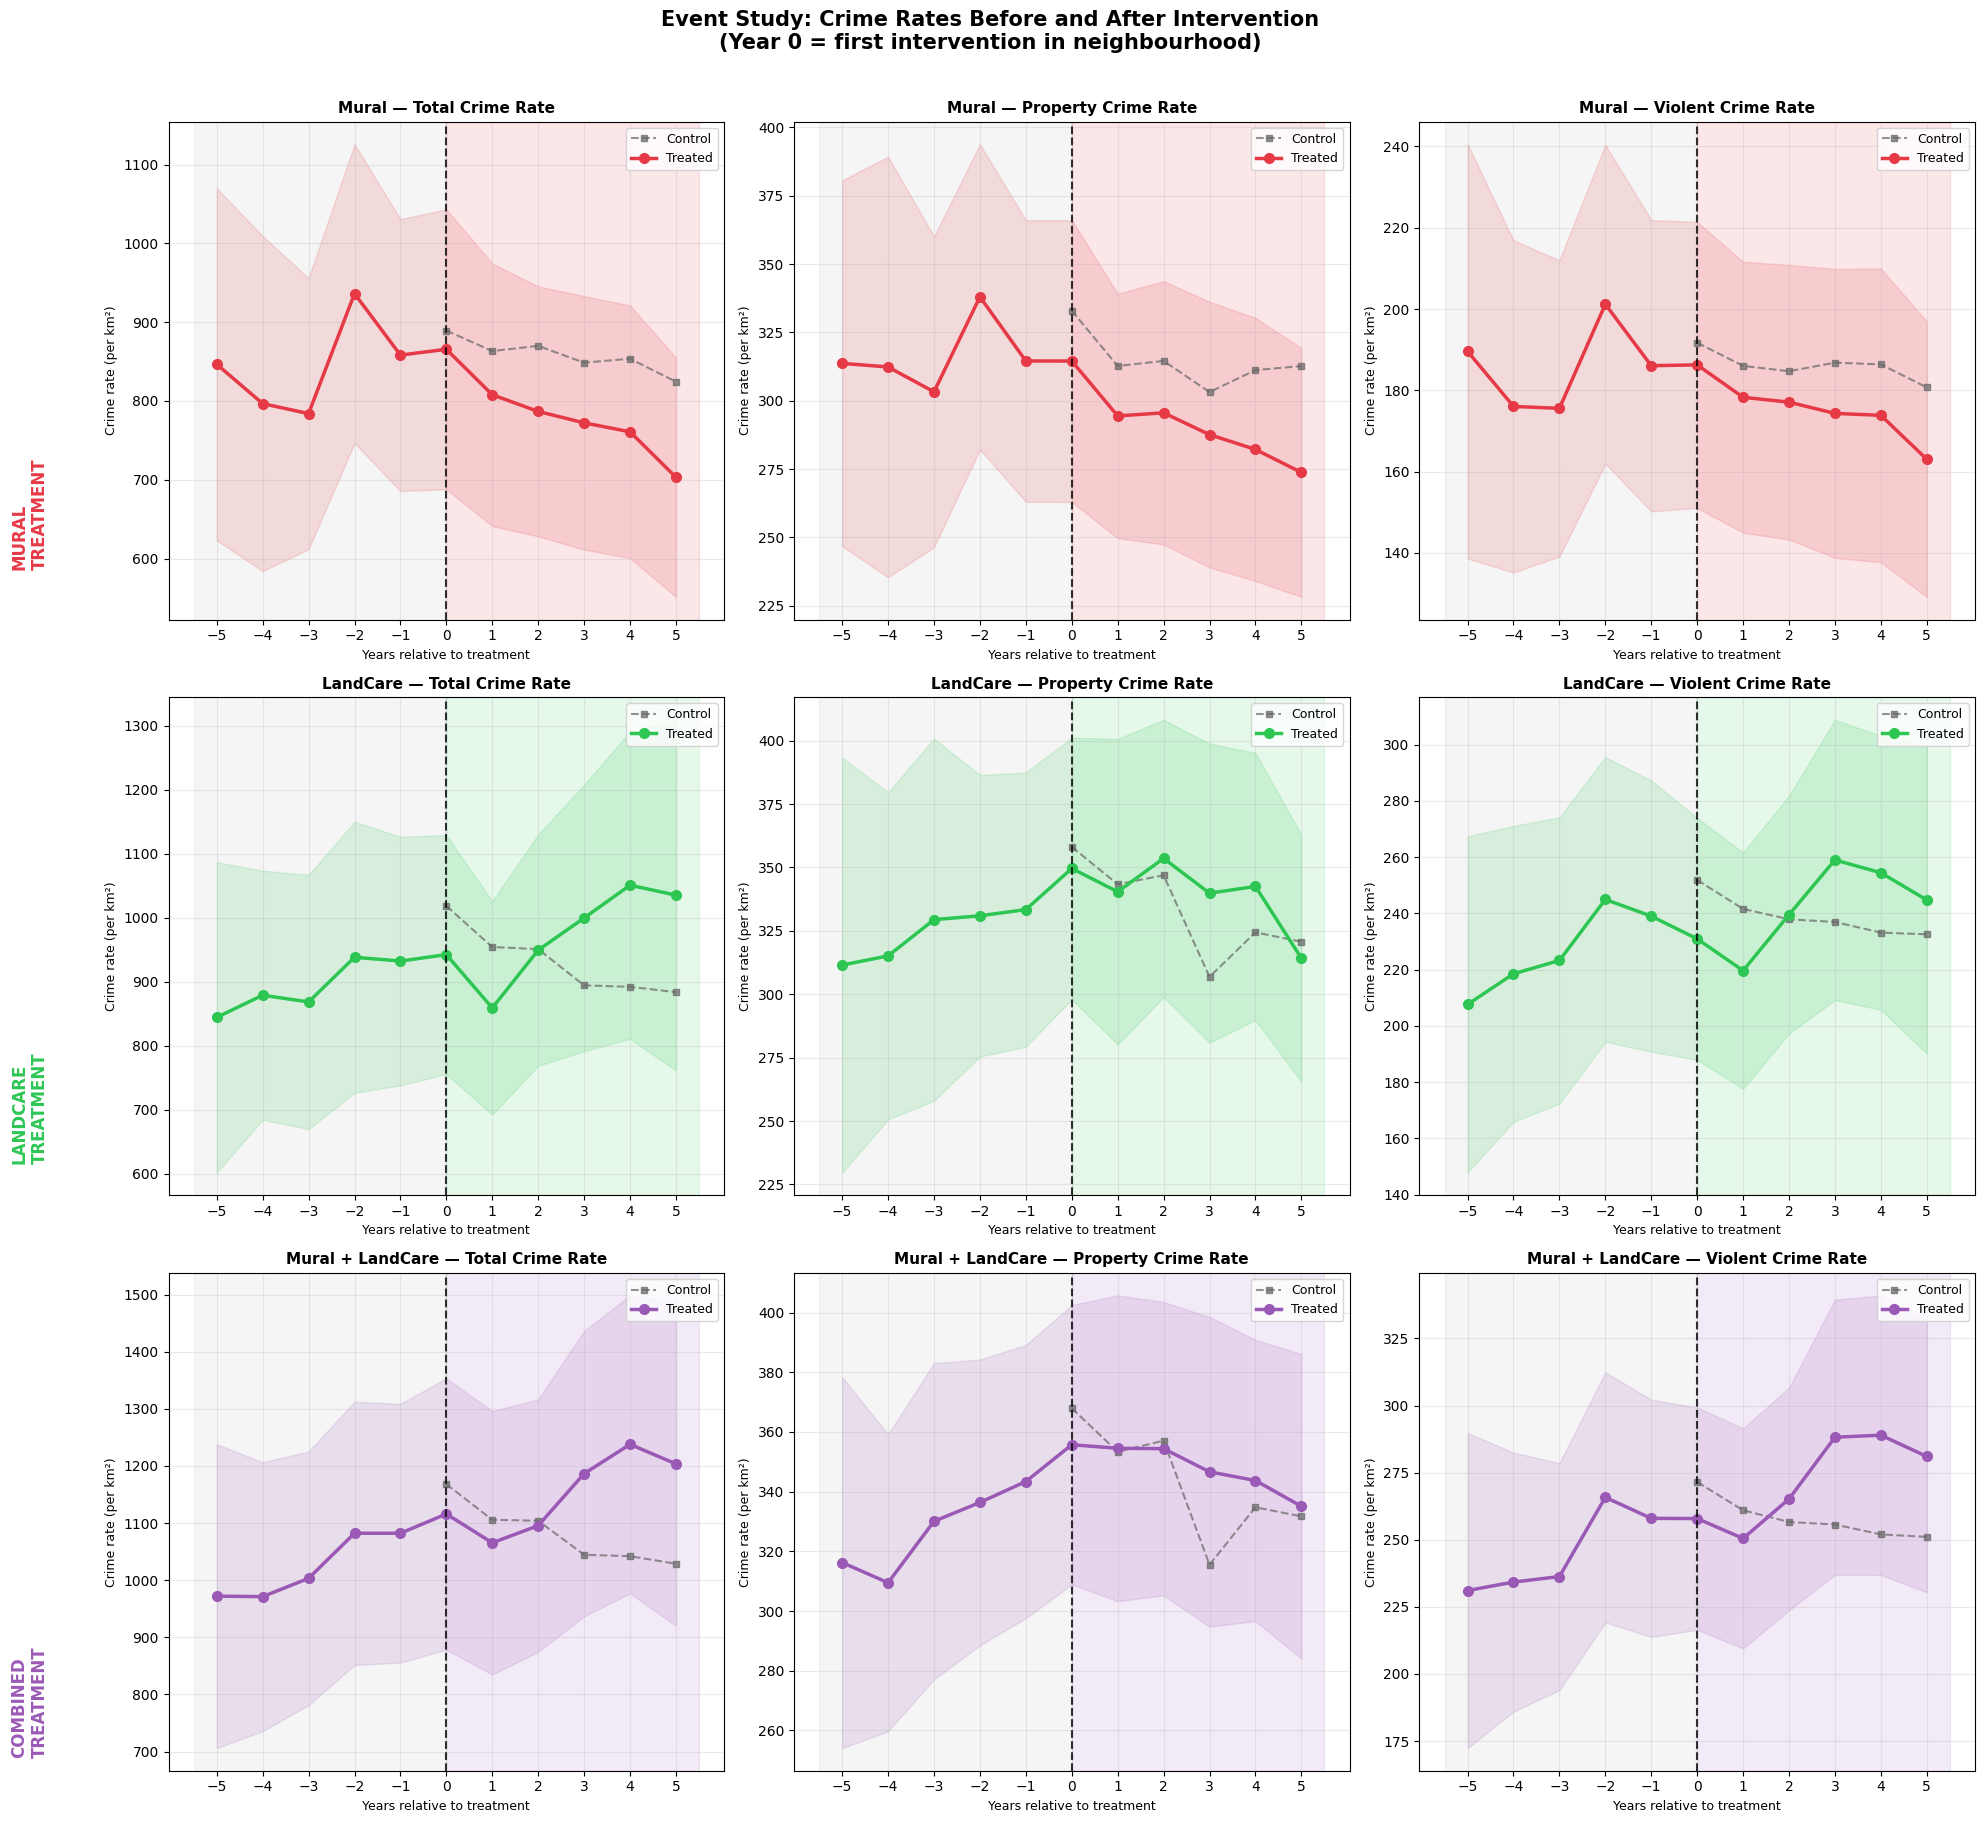

In [574]:
# Event study plot — 3 rows

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

plot_configs = [
    (did_mural,    mural_treated,  '#e63946', 'Mural',              0),
    (did_landcare, lc_treated,     '#2dc653', 'LandCare',           1),
    (did_both,     both_treated,   '#9b59b6', 'Mural + LandCare',   2),
]

for row, (did_panel_r, treated_list, color, label, row_idx) in enumerate(plot_configs):
    for col, response in enumerate(response_vars):
        plot_event_study_v2(
            did_panel_r, treated_list, response,
            f"{label} — {response_titles[response]}",
            color, axes[row][col]
        )

# Row labels
row_label_configs = [
    (0.73, '#e63946', 'MURAL\nTREATMENT'),
    (0.40, '#2dc653', 'LANDCARE\nTREATMENT'),
    (0.07, '#9b59b6', 'COMBINED\nTREATMENT'),
]
for y_pos, color, label in row_label_configs:
    fig.text(0.01, y_pos, label, fontsize=12, fontweight='bold',
             va='center', ha='left', color=color, rotation=90)

plt.suptitle(
    'Event Study: Crime Rates Before and After Intervention\n'
    '(Year 0 = first intervention in neighbourhood)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.savefig('outputs/did_event_study_3row.png', dpi=150, bbox_inches='tight')
plt.show()

#### Combined DiD (Mural + Greening) Key Findings

**Combined Treatment Effect (39 treated, 98 control neighborhoods):**
- Total crime fell by **62 incidents/km²** (p=0.029) which was significant.
- Property crime **increased by 17 incidents/km²** (p=0.044) which was significant.
- Violent crime fell by **9 incidents/km²** (p=0.079) which was marginal.

**Interpretation of the property crime increase:**
The positive property crime coefficient in combined-treatment neighborhoods is consistent with a **revitalisation effect** documented in urban regeneration literature. As neighborhoods improve (vacant lots are cleaned, murals signal community investment) foot traffic increases, businesses open, and there are more potential targets for property crime. This does not undermine the intervention's value; rather, it reflects the paradox of successful urban renewal.  Safety improvements can attract activity that temporarily elevates certain crime types.  Given enough time, crime trends downward in areas that have been successfully improved.

**Cross-method DiD summary:**

| Intervention | Total Crime | Property Crime | Violent Crime |
|---|---|---|---|
| Mural only | ✓ -89/km² | ✓ -23/km² | ✓ -10/km² |
| Greening only | ✓ -78/km² | ns | ✓ -23/km² |
| Combined | ✓ -62/km² | ✗ +17/km² | ~ -9/km² |

- Murals are the most consistent intervention — significant across all three crime categories.
- Greening has its strongest independent effect on violent crime.
- The combined effect on total crime is smaller than either intervention alone, suggesting **diminishing returns** when both are deployed in the same neighborhood.  Already high-need areas receiving both programs face structural challenges beyond what environmental interventions can address.
- Taken together, both interventions demonstrably reduce the most harmful crime (violent) while the property crime dynamics reflect broader neighbourhood change processes.

## Conclusions & Evaluation

This study examined whether two community-based environmental interventions - the Philadelphia Mural Arts Program and the Pennsylvania Horticultural Society's LandCare vacant lot greening program - are associated with measurable reductions in neighborhood crime rates across Philadelphia's 159 neighborhoods over an 18-year period (2006–2024).

---

### What Each Method Found

| Method | Research Question | Key Finding |
|---|---|---|
| **Negative Binomial Regression** | Where are interventions and crime concentrated? | Both interventions positively correlated with crime in cross-section, consistent with selection bias |
| **Random Forest Regression** | Which features best predict crime? | Mural density dominates prediction and ranks highly as an intervention for violent crime |
| **Spatial Lag Regression** | How does crime spread spatially? | Strong spatial autocorrelation (Moran's I ≈ 0.56); interaction term significant after spatial control |
| **K-Means Clustering** | What neighborhood profiles exist? | Three distinct profiles: Low Intervention, High LandCare/High Need, High Mural/High Density |
| **Difference-in-Differences** | Did interventions actually reduce crime? | Yes — murals reduced all crime types; Greening reduced violent crime; combined reduced total crime |

---

### Primary Research Question

**Do Philadelphia neighborhoods with higher mural density and LandCare greening exhibit lower crime rates, and did these interventions causally reduce crime after implementation?**

The answer is nuanced but affirmative:
- Cross-sectional methods (Methods 1–4) consistently show both interventions are deployed in high-crime, high-need areas, a selection bias that makes simple correlation analysis misleading
- The causal analysis (Method 5) controls for this by comparing each neighborhood to itself over time, and finds statistically significant crime reductions following both types of intervention

---

### Supporting Research Questions

**RQ1 — Spatial correlation:**
Mural and LandCare density are positively correlated with crime rates at the neighborhood level, reflecting deliberate program targeting of high-need areas rather than a causal relationship. This is consistent with prior literature and expected under any targeted urban intervention program.

**RQ2 — Crime type specificity:**
Murals reduce all three crime categories significantly. LandCare reduces violent crime but not property crime — consistent with CPTED theory, which predicts that environmental improvements deter opportunistic violent encounters but do not address the commercial and mobility factors driving property crime. Combined intervention neighborhoods show a property crime increase consistent with revitalization effects.

**RQ3 — Spatial spillover:**
Spatial lag regression confirms strong neighborhood-level crime clustering (ρ = 0.52–0.73). Crime in any neighborhood is substantially predicted by crime in adjacent neighborhoods, reinforcing the importance of spatially-aware policy deployment. The interaction term between mural and LandCare density remains significant even after controlling for spatial autocorrelation.

**RQ4 — Neighborhood profiles:**
K-Means clustering (k=3) identifies three distinct neighborhood typologies:
- **Low Intervention** (128 neighborhoods) — baseline residential fabric, lowest crime rates
- **High LandCare / High Need** (11 neighborhoods) — primarily Kensington and North Philadelphia, highest violent crime
- **High Mural / High Density** (20 neighborhoods) — primarily Center City and inner-ring neighborhoods, high property crime driven by commercial activity

**RQ5 — Causal before/after analysis:**
Difference-in-Differences provides the strongest evidence that interventions reduce crime:
- Murals produce the most consistent and robust effects across all crime types
- LandCare's strongest effect is on violent crime
- The synergy interaction term (mural × LandCare co-presence) is negative and significant in both Negative Binomial and Spatial Lag models, suggesting non-additive crime suppression where both programs operate simultaneously

---

### Limitations

- **Selection bias** — both programs target high-crime, high-vacancy areas; cross-sectional analysis cannot establish causality
- **Temporal confounding** — the 2006–2024 study period encompasses major structural changes in Philadelphia (gentrification, opioid crisis, COVID-19); year fixed effects absorb city-wide trends but not neighborhood-specific shocks
- **LandCare snapshot** — the dataset reflects currently maintained lots only; lots that were greened and later abandoned are not distinguishable from never-greened lots
- **Dosage heterogeneity** — treated neighborhoods range from 1 to 28 murals and 1 to 897 LandCare parcels; the DiD treats all treated units equally regardless of intensity
- **Unmeasured confounders** — socioeconomic controls (income, unemployment, housing vacancy rates) were not included; their inclusion would strengthen causal claims

---

### Policy Implications

- **Murals** are the more versatile intervention — reducing total, property, and violent crime across a wide range of neighborhood types
- **LandCare** is most effective at reducing violent crime in high-vacancy areas — deployment should prioritize neighborhoods with both high vacancy rates and high violent crime
- **Combined deployment** reduces total crime but may temporarily increase property crime as neighborhoods improve — policymakers should anticipate this revitalization dynamic
- **Cluster-based deployment** — concentrating interventions in spatially contiguous neighborhoods — may amplify effects through spatial spillover

---

### Future Work

- Incorporate socioeconomic controls (Census ACS data) to strengthen causal identification
- Extend the DiD to a synthetic control design for individual neighborhood case studies
- Examine heterogeneous treatment effects — does the mural effect vary by content, size, or community involvement?
- Replicate the analysis in comparable post-industrial cities (Baltimore, Detroit, Pittsburgh) to test external validity

In [575]:
# Confirm required variables are in scope
checks = {
    'rf_importances'  : 'rf_importances' in dir(),
    'nb_results'      : 'nb_results' in dir(),
    'sl_results'      : 'sl_results' in dir(),
    'w_fixed'         : 'w_fixed' in dir(),
    'feat'            : 'feat' in dir(),
    'neighborhoods'   : 'neighborhoods' in dir(),
}
for var, exists in checks.items():
    print(f"  {'✓' if exists else '✗'} {var}")

  ✓ rf_importances
  ✓ nb_results
  ✓ sl_results
  ✓ w_fixed
  ✓ feat
  ✓ neighborhoods


## Extra Resources: Extended Visualisations

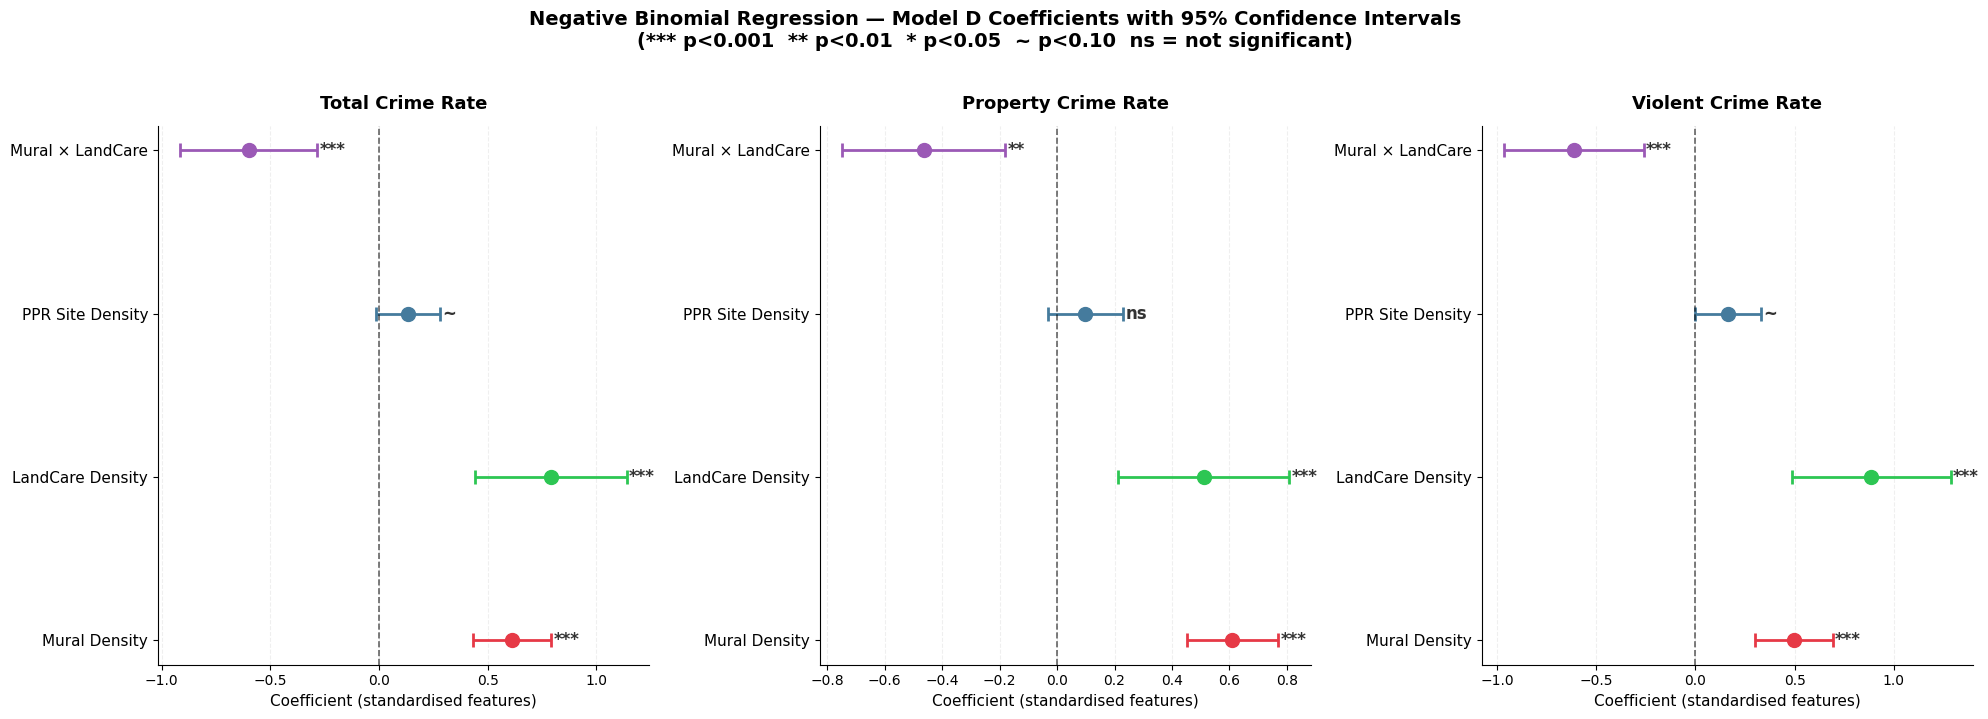

In [576]:
# Negative Binomial Coefficient Plot (Model D)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

feature_order = ['mural_density', 'landcare_density', 'ppr_site_density', 'mural_x_landcare']

for ax, response in zip(axes, response_vars):
    r = nb_results[response]['D']

    coefs  = [r.params.get(f, 0)  for f in feature_order]
    pvals  = [r.pvalues.get(f, 1) for f in feature_order]
    errors = [r.bse.get(f, 0)     for f in feature_order]
    labels = [feature_labels[f]   for f in feature_order]
    colors = [feature_colors[f]   for f in feature_order]

    # 95% CI error bars
    ci = [1.96 * e for e in errors]

    y_pos = range(len(feature_order))

    for i, (coef, err, pval, color, label) in enumerate(
            zip(coefs, ci, pvals, colors, labels)):
        ax.errorbar(
            coef, i,
            xerr=err,
            fmt='o',
            color=color,
            markersize=10,
            capsize=5,
            capthick=2,
            linewidth=2,
            label=label
        )
        # Significance stars
        if pval < 0.001:   sig = '***'
        elif pval < 0.01:  sig = '**'
        elif pval < 0.05:  sig = '*'
        elif pval < 0.10:  sig = '~'
        else:              sig = 'ns'

        ax.text(
            coef + err + 0.01,
            i,
            sig,
            va='center', ha='left',
            fontsize=12, color='#333333', fontweight='bold'
        )

    # Zero reference line
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Coefficient (standardised features)', fontsize=11)
    ax.set_title(response_labels[response], fontsize=13, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle(
    'Negative Binomial Regression — Model D Coefficients with 95% Confidence Intervals\n'
    '(*** p<0.001  ** p<0.01  * p<0.05  ~ p<0.10  ns = not significant)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/viz_nb_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

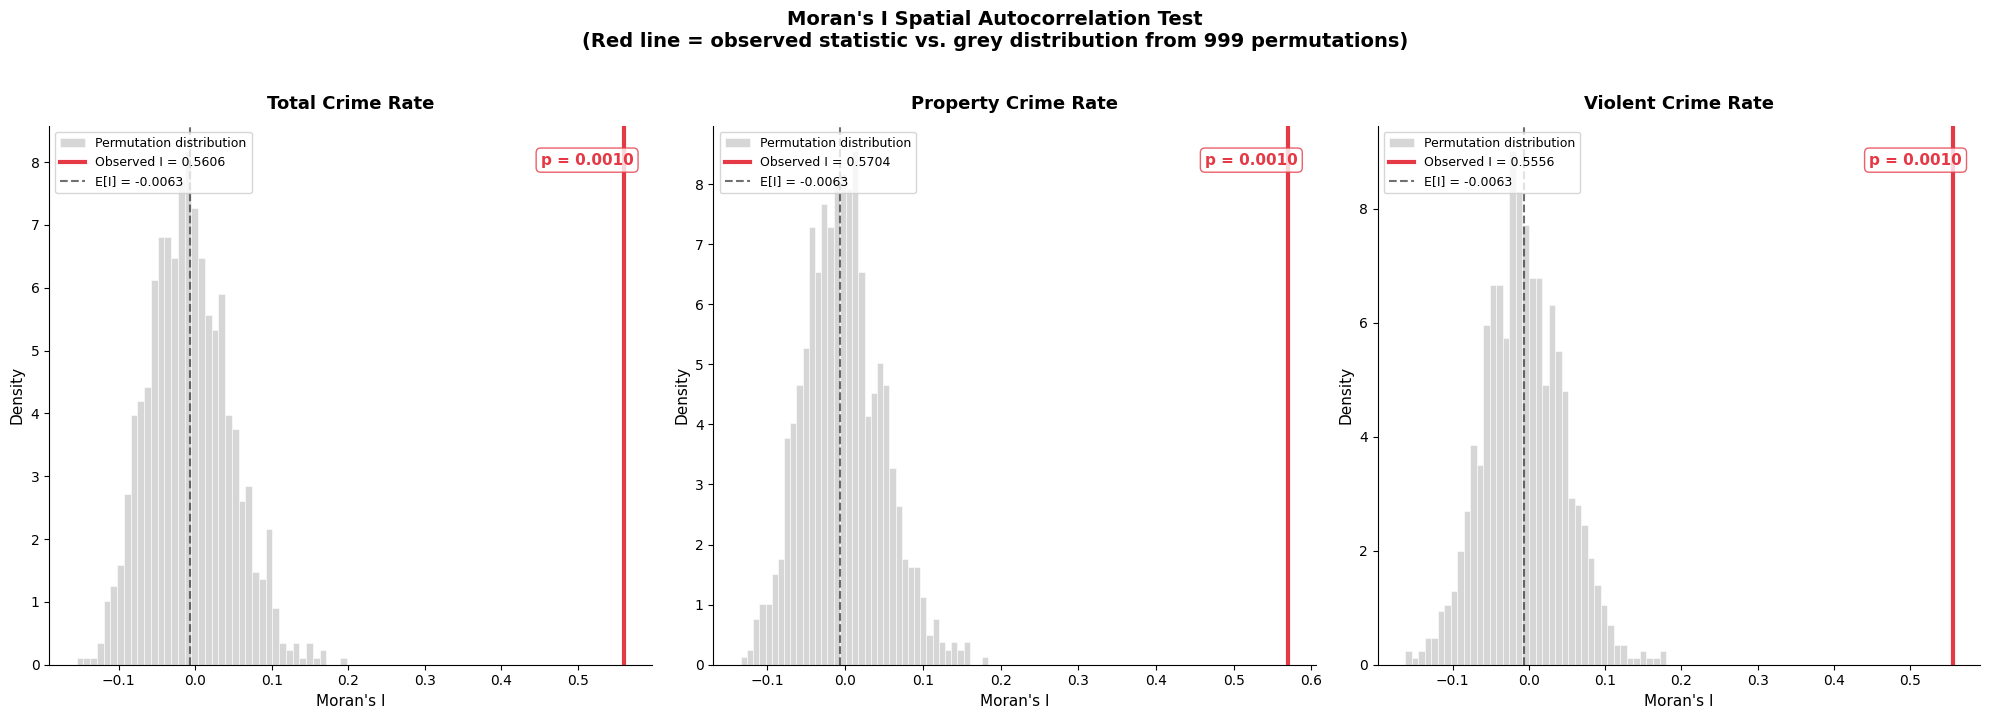

In [577]:
# Moran's I Spatial Autocorrelation

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

moran_colors = {
    'crime_rate_total'   : '#9b59b6',
    'crime_rate_property': '#9b59b6',
    'crime_rate_violent' : '#9b59b6',
}

for ax, response in zip(axes, response_vars):
    y = feat[response].values
    mi = esda.Moran(y, w_fixed)

    # Reference distribution from permutations
    ax.hist(
        mi.sim,
        bins=40,
        color='#cccccc',
        edgecolor='white',
        linewidth=0.5,
        label='Permutation distribution',
        density=True,
        alpha=0.8
    )

    # Observed Moran's I
    ax.axvline(
        mi.I,
        color='#e63946',
        linewidth=3,
        linestyle='-',
        label=f"Observed I = {mi.I:.4f}"
    )

    # Expected value under null
    ax.axvline(
        mi.EI,
        color='#333333',
        linewidth=1.5,
        linestyle='--',
        alpha=0.7,
        label=f"E[I] = {mi.EI:.4f}"
    )

    ax.set_xlabel("Moran's I", fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(response_labels[response], fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Annotation
    ax.text(
        0.97, 0.95,
        f"p = {mi.p_sim:.4f}",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=11, fontweight='bold',
        color='#e63946',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e63946', alpha=0.8)
      )

plt.suptitle(
    "Moran's I Spatial Autocorrelation Test\n"
    "(Red line = observed statistic vs. grey distribution from 999 permutations)",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/viz_morans_i.png', dpi=150, bbox_inches='tight')
plt.show()

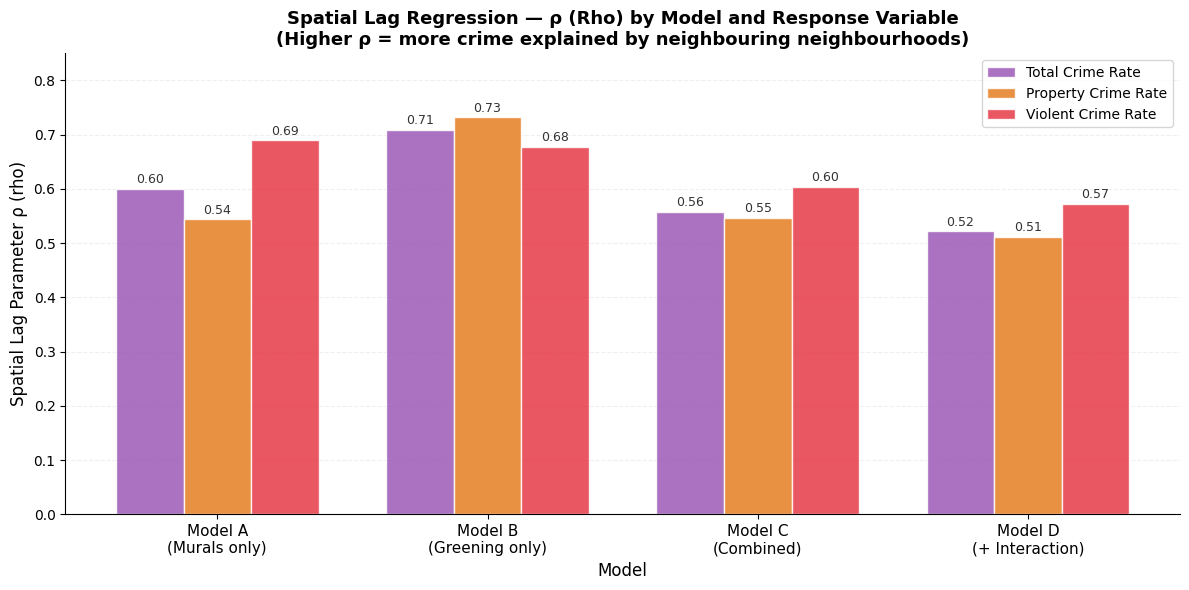

In [578]:
# Spatial Lag rho comparison

fig, ax = plt.subplots(figsize=(12, 6))

models_list  = ['A', 'B', 'C', 'D']
model_labels = ['Model A\n(Murals only)', 'Model B\n(Greening only)',
                'Model C\n(Combined)', 'Model D\n(+ Interaction)']

x    = np.arange(len(models_list))
width = 0.25

response_plot_colors = {
    'crime_rate_total'   : '#9b59b6',
    'crime_rate_property': '#e67e22',
    'crime_rate_violent' : '#e63946',
}

for i, response in enumerate(response_vars):
    rho_vals = [sl_results[response][m].rho for m in models_list]
    bars = ax.bar(
        x + i * width,
        rho_vals,
        width,
        label=response_labels[response],
        color=response_plot_colors[response],
        edgecolor='white',
        linewidth=1.0,
        alpha=0.85
    )
    for bar, val in zip(bars, rho_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.2f}',
            ha='center', va='bottom',
            fontsize=9, color='#333333'
        )

ax.set_ylabel('Spatial Lag Parameter \u03c1 (rho)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title(
    'Spatial Lag Regression \u2014 \u03c1 (Rho) by Model and Response Variable\n'
    '(Higher \u03c1 = more crime explained by neighbouring neighbourhoods)',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('outputs/viz_spatial_lag_rho.png', dpi=150, bbox_inches='tight')
plt.show()